# Le Mirouer des simples âmes — Análisis computacional

Análisis del texto de Marguerite Porete (transcripción del ms. Chantilly,
Wikisource, s. XV). Este notebook es autocontenido: solo necesita el
archivo `.txt` crudo descargado de Wikisource.

**Pasos:**
1. Cargar el texto crudo
2. Resolver las marcas de incertidumbre de transcripción `(?)`
3. Anteponer el poema inicial (que falta en la descarga estándar de Wikisource)
4. Tokenizar y calcular frecuencias
5. Dividir por capítulo y rastrear vocabulario místico clave
6. Cruzar con los títulos reales de los 139 capítulos
7. Visualizar


In [1]:
import re
import csv
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import networkx as nx  # pip install networkx si no lo tenés instalado

# --------------------------------------------------------------------
# CONFIGURACIÓN: cambiá esta ruta al .txt que descargaste de Wikisource
# --------------------------------------------------------------------
RUTA_ARCHIVO_CRUDO = "Margarita.txt"

# --------------------------------------------------------------------
# Paleta violeta/rosa para todos los gráficos de esta notebook
# --------------------------------------------------------------------
PALETA = {
    "violeta_oscuro": "#4a2545",
    "violeta":        "#6a4c93",
    "orquidea":       "#9163cb",
    "magenta":        "#ae3ec9",
    "fucsia":         "#c86dd7",
    "rosa_fuerte":    "#d6336c",
    "rosa":           "#e75a9d",
    "rosa_palido":    "#f2a6c9",
}
GRADIENTE_VIOLETA_ROSA = [PALETA["violeta_oscuro"], PALETA["violeta"], PALETA["orquidea"],
                          PALETA["magenta"], PALETA["fucsia"], PALETA["rosa_fuerte"],
                          PALETA["rosa"], PALETA["rosa_palido"]]

def degradado(n):
    """Devuelve n colores tomados del degradado violeta->rosa."""
    import matplotlib.colors as mcolors
    cmap = mcolors.LinearSegmentedColormap.from_list("violeta_rosa", GRADIENTE_VIOLETA_ROSA)
    return [cmap(i / max(n - 1, 1)) for i in range(n)]

plt.rcParams["axes.facecolor"] = "#fffafc"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#4a2545"
plt.rcParams["text.color"] = "#3d2645"
plt.rcParams["axes.labelcolor"] = "#3d2645"
plt.rcParams["xtick.color"] = "#3d2645"
plt.rcParams["ytick.color"] = "#3d2645"


## 1. Diccionario de resolución de marcas `(?)`

Wikisource marca con `(?)` las letras que el/la transcriptor/a no pudo confirmar con certeza en el manuscrito. Resolvemos las formas de alta frecuencia con este diccionario (basado en el contexto y el francés medio atestiguado); lo que no se resuelve queda documentado, no se inventa.

In [2]:
DICCIONARIO_RESOLUCION = {
    "po(?)r": "pour", "Po(?)r": "Pour",
    "por(?)ce": "pource", "Por(?)ce": "Pource",
    "po(?)rce": "pource", "po(?)ce": "pource",
    "vo(?)s": "vous", "Vo(?)s": "Vous", "vo(?)": "vous",
    "po(?)rquoy": "pourquoy", "Po(?)rquoy": "Pourquoy",
    "por(?)quoy": "pourquoy", "Por(?)quoy": "Pourquoy",
    "po(?)quoy": "pourquoy", "p(?)rquoy": "pourquoy",
    "pr(?)manable": "permanable", "pr(?)manablement": "permanablement",
    "pr(?)manables": "permanables",
    "chapp(?)": "chappitre", "chappitr(?)": "chappitre",
    "chap(?)": "chappitre", "cha(?)": "chappitre", "chappr(?)": "chappitre",
    "no(?)s": "nous", "no(?)us": "nous", "No(?)s": "Nous",
    "pr(?)fection": "perfection",
    "por(?)tant": "pourtant", "po(?)rtant": "pourtant",
    "nonpo(?)rtant": "nonpourtant", "po(?)rtantne": "pourtantne",
    "amo(?)r": "amour", "Amo(?)r": "Amour",
    "pr(?)sonne": "personne", "pr(?)sonnes": "personnes",
    "jo(?)r": "jour", "tousjo(?)rs": "tousjours",
    "ch(?)": "chose", "ch(?)un": "chescun",
    "v(?)re": "vostre", "vr(?)re": "vostre", "vs(?)re": "vostre",
    "ns(?)re": "nostre", "n(?)re": "nostre", "no(?)re": "nostre",
    "pr(?)pre": "propre", "prp(?)re": "propre", "prp(?)rement": "proprement",
    "pr(?)mier": "premier",
    "pr(?)le": "parle", "parl(?)r": "parler", "pr(?)ler": "parler",
    "pl(?)s": "plus", "p(?)r": "pour",
    "pr(?)": "pour",
    "tr(?)s": "tres", "tr(?)nité": "trinité", "t(?)nite": "trinité",
    "t(?)inté": "trinité", "trinité(?)": "trinité",
    "l(?)e": "lettre",
    "por(?)": "pource", "por(?)roie": "pourroie",
    "meille(?)r": "meilleur",
    "espr(?)it": "esperit",
    "u(?)eu": "ueil",
    "q(?)treving": "quatreving",
    "pr(?)mis": "promis",
    "pr(?)faictes": "parfaictes", "pr(?)faicte": "parfaicte",
    "pr(?)faictement": "parfaictement", "pr(?)fait": "parfait",
    "pr(?)durablement": "perdurablement",
    "pr(?)dre": "prendre",
    "i(?)l": "ueil",
    "dont(?)": "dont", "donner(?)": "donner",
    "auc(?)n": "aucun",
    "gou(?)vernent": "gouvernent", "go(?)verner": "gouverner",
    "escri(?)tures": "escriptures",
    "esp(?)alement": "especialement",
    "laq(?)lle": "laquelle", "laq(?)el": "laquel",
    "qu(?)rir": "querir", "q(?)rt": "quart", "q(?)nt": "quant",
    "q(?)n": "quant", "q(?)mmt": "quant", "q(?)v": "quel",
    "q(?)traire": "quatraire", "q(?)seille": "quelseille",
    "N(?)yent": "Nyent",
}

PUNTUACION_BORDE = ".,;:!\u00bb\u00ab\"\u2019\'"


def resolver_incertidumbres(texto):
    """Resuelve las marcas '(?)' con el diccionario; documenta lo que no
    puede resolver (les quita la marca sin inventar la letra)."""
    no_resueltos = Counter()
    patron_token = re.compile(r"\S*\(\?\)\S*")

    def reemplazar(match):
        token_orig = match.group(0)
        nucleo, pre, post = token_orig, "", ""
        while nucleo and nucleo[0] in PUNTUACION_BORDE:
            pre += nucleo[0]; nucleo = nucleo[1:]
        while nucleo and nucleo[-1] in PUNTUACION_BORDE:
            post = nucleo[-1] + post; nucleo = nucleo[:-1]

        if nucleo in DICCIONARIO_RESOLUCION:
            return pre + DICCIONARIO_RESOLUCION[nucleo] + post
        low = nucleo[0].lower() + nucleo[1:] if nucleo else nucleo
        if low in DICCIONARIO_RESOLUCION:
            resuelto = DICCIONARIO_RESOLUCION[low]
            if nucleo[:1].isupper():
                resuelto = resuelto[0].upper() + resuelto[1:]
            return pre + resuelto + post
        no_resueltos[token_orig] += 1
        return token_orig.replace("(?)", "")

    return patron_token.sub(reemplazar, texto), no_resueltos


## 2. El poema inicial

Falta en la descarga estándar de Wikisource (queda en una subpágina aparte, *"Poème initial"*). Son 4 estrofas de 7 versos — no solo la primera, que es lo único que suele aparecer citado. La 3ª estrofa se autorreferencia al capítulo 13 del libro, anticipando la humillación de Razón que vas a ver más abajo en el gráfico de evolución del vocabulario.

In [3]:
POEMA_INICIAL = """Vous qui en ce livre lirez
Se bien le voulez entendre
Pensez ad ce que vous direz
Car il est fort a comprendre
Humilité vous fault prendre
Qui de science est tresoriere
Et des aultres vertuz la mere.

Theologiens ne aultres clers
Point n'en aurez l'entendement
Tant aiez les engins clers
Se n'y procedez humblement
Et que amor et foy ensement
Vous facent surmonter raison
Qui dames sont de la maison.

Raison mesmes nous tesmoigne
Ou .xiiie. de ce livre
Chappitre, et n'en a vergoigne
Que amor et foy la font vivre
Et d'elles point ne se delivre
Car sur elle ont seigneurie
Par quoy il fault qu'elle s'umilie.

Humiliez dont vos sciences
Qui sont de raison fondées
Et mettez toutes voz fiances
En celles qui sont données
D'amor par foy eluminées
Et ainsy comprendrez ce livre
Qui d'amor fait l'ame vivre.
"""
print(POEMA_INICIAL)


Vous qui en ce livre lirez
Se bien le voulez entendre
Pensez ad ce que vous direz
Car il est fort a comprendre
Humilité vous fault prendre
Qui de science est tresoriere
Et des aultres vertuz la mere.

Theologiens ne aultres clers
Point n'en aurez l'entendement
Tant aiez les engins clers
Se n'y procedez humblement
Et que amor et foy ensement
Vous facent surmonter raison
Qui dames sont de la maison.

Raison mesmes nous tesmoigne
Ou .xiiie. de ce livre
Chappitre, et n'en a vergoigne
Que amor et foy la font vivre
Et d'elles point ne se delivre
Car sur elle ont seigneurie
Par quoy il fault qu'elle s'umilie.

Humiliez dont vos sciences
Qui sont de raison fondées
Et mettez toutes voz fiances
En celles qui sont données
D'amor par foy eluminées
Et ainsy comprendrez ce livre
Qui d'amor fait l'ame vivre.



## 3. Cargar, limpiar y armar el corpus completo

In [4]:
with open(RUTA_ARCHIVO_CRUDO, "r", encoding="utf-8-sig", newline="") as f:
    texto_crudo = f.read()

total_marcas = texto_crudo.count("(?)")
texto_limpio, no_resueltos = resolver_incertidumbres(texto_crudo)

corpus_completo = POEMA_INICIAL + "\n\n" + texto_limpio

print(f"Marcas '(?)' originales: {total_marcas}")
print(f"Resueltas por diccionario: {total_marcas - sum(no_resueltos.values())}")
print(f"Sin resolver (solo se les quitó la marca, ver 'no_resueltos'): "
      f"{sum(no_resueltos.values())}")


Marcas '(?)' originales: 833
Resueltas por diccionario: 673
Sin resolver (solo se les quitó la marca, ver 'no_resueltos'): 160


In [5]:
# Si querés inspeccionar qué quedó sin resolver:
for token, cnt in no_resueltos.most_common(15):
    print(f"  {token} -> {token.replace('(?)', '')}  (x{cnt})")


  (?) ->   (x4)
  po(?) -> po  (x3)
  (?)ce -> ce  (x2)
  tren(?) -> tren  (x2)
  q’i(?)l -> q’il  (x2)
  m(?)cie -> mcie  (x1)
  m(?)rveille -> mrveille  (x1)
  d’elles(?), -> d’elles,  (x1)
  d’ores(?)en(?)anant -> d’oresenanant  (x1)
  o(?)tredit -> otredit  (x1)
  cou(?)te -> coute  (x1)
  (?)tredit, -> tredit,  (x1)
  purg(?)toire -> purgtoire  (x1)
  q(?)v(?)ties -> qvties  (x1)
  p(?)v(?)ties. -> pvties.  (x1)


## 4. Tokenización, stopwords y frecuencias

In [6]:
STOPWORDS_FR_MEDIO = {
    "et", "de", "la", "le", "les", "des", "du", "en", "que", "qui", "qu",
    "ne", "se", "sa", "son", "ses", "ce", "ceste", "cest", "cette", "cel",
    "celle", "ceulx", "cil", "a", "au", "aux", "par", "pour", "pource",
    "por", "sur", "sont", "est", "estoit", "estre", "fut", "furent",
    "il", "elle", "ilz", "elles", "je", "tu", "nous", "vous", "on",
    "mais", "si", "car", "comme", "comment", "ou", "où", "donc", "puis",
    "quant", "quand", "quelle", "quel", "quelles", "quels",
    "dont", "dedans", "dehors", "avec", "sans", "entre", "vers",
    "un", "une", "ung", "unes", "uns", "point", "pas", "plus", "moins",
    "tout", "toute", "tous", "toutes", "tres", "bien", "ainsi", "ainsy",
    "lors", "or", "orendroit", "encores", "encore", "jamais", "toujours",
    "tousjours", "aussi", "aussy", "meme", "mesme", "mesmes", "mesmement",
    "moy", "toy", "luy", "leur", "leurs", "nostre", "vostre", "notre",
    "votre", "mon", "ma", "mes", "ton", "ta", "tes", "soit", "seroit",
    "sera", "estoient", "avoit", "avoient", "ait", "aient", "as",
    "ont", "avons", "avez", "fait", "faire", "faisoit", "font",
    "dit", "dist", "disoit", "dire", "diroit", "dis", "dites",
    "cy", "ycy", "ci", "ceans", "y",
    "es", "ès",
    "premier", "premiere", "secondement", "aultre", "aultres", "autre",
    "autres", "chose", "choses", "chascun", "chescun", "chacun",
}


def tokenizar(texto):
    texto = texto.lower().replace("\u2019", "'")
    return re.findall(
        r"[a-zàâäéèêëïîôöùûüçœæ]+(?:['-][a-zàâäéèêëïîôöùûüçœæ]+)*", texto
    )


todas_palabras = tokenizar(corpus_completo)
frecuencia_total = Counter(todas_palabras)

print(f"Total de palabras: {len(todas_palabras)}")
print(f"Vocabulario único: {len(frecuencia_total)}")


Total de palabras: 54151
Vocabulario único: 4587


In [7]:
top_sin_stop = [(p, c) for p, c in frecuencia_total.most_common()
                if p not in STOPWORDS_FR_MEDIO][:20]
for palabra, conteo in top_sin_stop:
    print(f"  {palabra}: {conteo}")


  ame: 510
  dieu: 447
  amor: 406
  amour: 386
  l'ame: 315
  raison: 312
  c'est: 263
  divine: 258
  voulenté: 237
  bonté: 226
  nient: 204
  peut: 200
  me: 185
  vouloir: 181
  telle: 169
  mie: 157
  n'est: 143
  qu'il: 141
  nul: 136
  vie: 135


## 5. División por capítulo + vocabulario místico clave

In [8]:
VOCABULARIO_CLAVE = {
    "ame": ["ame", "ames", "l'ame"],
    "amour": ["amour", "amor", "amours"],
    "nient/néant": ["nient", "nyent", "neant"],
    "franchise": ["franchise", "franchises", "franc", "franche", "enfranchie"],
    "volenté": ["volente", "volenté", "voulente", "voulenté"],
    "vertu(s)": ["vertu", "vertus", "vertuz"],
    "raison": ["raison", "raisons"],
    "esperit": ["esperit", "esperits", "esperiz"],
    "aniente/anientie": ["aniente", "anientie", "anienti", "anientissement",
                          "adnientifs"],
    "seigneur": ["seigneur", "seigneurs", "seigneurie"],
    "sire": ["sire"],
    "deité": ["deité", "deite"],
    "dieu": ["dieu", "dieux"],
    "foy": ["foy"],
    "esperance": ["esperance", "esperanche"],
    "charité": ["charité", "charite"],
}

# --------------------------------------------------------------------
# MAPA DE GÉNERO GRAMATICAL — verificado término por término contra el
# origen latino (ver documento base de investigación, sección 4.1).
# Se centraliza acá para que todas las secciones posteriores de esta
# notebook (concordancias, "quién habla", red de interacción) usen la
# MISMA clasificación, sin repetir ni contradecir criterios.
#
# Nota importante sobre "amor": en latín amor, amoris es MASCULINO
# (como dolor, clamor, labor). Su feminización como "Dame Amour" es una
# convención de la lírica cortés ("bele Amors") que va CONTRA el género
# heredado del latín — no una herencia pasiva como el resto de los
# términos femeninos de esta lista (todos los cuales sí son femeninos
# por descendencia directa: ratio, virtus, caritas, veritas, fides,
# anima, ecclesia, deitas, trinitas son femeninos en latín clásico).
# --------------------------------------------------------------------
GENERO_GRAMATICAL = {
    # -- FEMENINOS por herencia directa del latín --
    "ame": "fem",            # < anima, animae
    "raison": "fem",         # < ratio, rationis
    "vertu(s)": "fem",       # < virtus, virtutis
    "charité": "fem",        # < caritas, caritatis
    "foy": "fem",            # < fides, fidei
    "esperance": "fem",      # < *sperantia (spes, spei)
    "verité": "fem",         # < veritas, veritatis (no está en VOCABULARIO_CLAVE,
                              # se incluye igual por completitud del mapa)
    "deité": "fem",          # < deitas, deitatis
    "trinité": "fem",        # < trinitas, trinitatis (no tokenizable como
                              # "personaje"; se documenta por completitud)
    "franchise": "fem",
    "volenté": "fem",
    "nient/néant": "masc",   # "le néant" — MASCULINO (Dictionnaire Académie française).
                              # OJO: no es "la nada femenina" — es el Alma (fem., "l'ame")
                              # o la Vida (fem., "vie") las que se aniquilan CAYENDO
                              # DENTRO de un vacío gramaticalmente masculino. La
                              # "anientie" en "l'ame anientie" es un participio que
                              # concuerda con "ame" (fem.), no un género propio de "néant".
    "aniente/anientie": "participio (concuerda con el sustantivo que modifica, no género propio)",
    # -- FEMENINO por convención cortés, CONTRA el género latino --
    "amour": "fem*",         # < amor, amoris (MASCULINO en latín) — ver nota arriba
    # -- MASCULINOS por herencia directa del latín --
    "dieu": "masc",          # < deus, dei
    "esperit": "masc",       # < spiritus, spiritus
    "seigneur": "masc",      # < senior, senioris
    "sire": "masc",          # < senior, senioris
}

print("Mapa de género gramatical (verificado contra el latín):\n")
for termino, genero in GENERO_GRAMATICAL.items():
    etiquetas = {"fem": "FEMENINO", "masc": "MASCULINO",
                 "fem*": "FEMENINO (excepción cortés, latín masc.)"}
    etiqueta = etiquetas.get(genero, genero.upper())
    print(f"  {termino:20s} {etiqueta}")


Mapa de género gramatical (verificado contra el latín):

  ame                  FEMENINO
  raison               FEMENINO
  vertu(s)             FEMENINO
  charité              FEMENINO
  foy                  FEMENINO
  esperance            FEMENINO
  verité               FEMENINO
  deité                FEMENINO
  trinité              FEMENINO
  franchise            FEMENINO
  volenté              FEMENINO
  nient/néant          MASCULINO
  aniente/anientie     PARTICIPIO (CONCUERDA CON EL SUSTANTIVO QUE MODIFICA, NO GÉNERO PROPIO)
  amour                FEMENINO (excepción cortés, latín masc.)
  dieu                 MASCULINO
  esperit              MASCULINO
  seigneur             MASCULINO
  sire                 MASCULINO


In [9]:
def dividir_por_capitulos(texto):
    lineas = texto.splitlines()
    capitulos = defaultdict(list)
    cap_actual = 0  # 0 = poema inicial + prólogo previo a la numeración "1"
    for linea in lineas:
        if re.fullmatch(r"\d{1,3}", linea.strip()):
            cap_actual = int(linea.strip())
            continue
        capitulos[cap_actual].append(linea)
    return {k: "\n".join(v) for k, v in capitulos.items()}


capitulos = dividir_por_capitulos(corpus_completo)
print(f"Capítulos detectados: {len([k for k in capitulos if k > 0])}")


Capítulos detectados: 139


In [10]:
filas_clave = []
for num_cap in sorted(capitulos.keys()):
    tokens_cap = tokenizar(capitulos[num_cap])
    cnt_cap = Counter(tokens_cap)
    fila = {"capitulo": num_cap, "total_palabras_capitulo": len(tokens_cap)}
    for concepto, formas in VOCABULARIO_CLAVE.items():
        fila[concepto] = sum(cnt_cap.get(f, 0) for f in formas)
    filas_clave.append(fila)


## 6. Títulos reales de los 139 capítulos

Transcriptos desde la tabla de capítulos de Wikisource (orden secuencial, verificado contra los encabezados que ya aparecen en el propio corpus).

In [11]:
TITULOS_CAPITULOS = [
    "Le cplogue.",
    "De l'entreprinse d'amor et pourquoy elle fist faire ce livre.",
    "Icy parle amor des commandemens de nostre treze saincte eglise.",
    "De la noble vertu de charité et comment elle ne obeyst sinon a amor.",
    "De la vie qui s'appellé pais de charité en vie adnientie.",
    "Comment l'ame vivant en paix de charité prent congié aux vertuz.",
    "Comment ceste ame ne fait compte de nulle rien qui soit.",
    "Comment raison s'esbahyst de ce que l'ame lesse les vertuz.",
    "Comment telles ames n'ont point de propre voulente.",
    "Comment amour nomme ceste ame par douze noms a la requeste de raison, et por les actifs.",
    "Comment a la requeste de raison amor donne connoissance de ceste ame aux vrais contemplatifs en declarant neuf poins.",
    "Le vray entendement de ce que ce livre a dit de l'ame adnientie n'a point de voulenté.",
    "Comment raison est contente de la declaration des choses dessusdictes pour les actifs et contemplatifs mais elle demande encore por les communes gens.",
    "Comment ceste ame par foy a cognoissance de dieu.",
    "Icy parle haultement du saint sacrement de l'autel.",
    "Icy respont amor a raison ad ce qu'elle a dit que l'ame scait tout et ne scait nient.",
    "Icy respont amor a raison ad ce qu'elle a dit que ces ames donnent a nature ce qu'elle demande.",
    "Comment telles creatures ne sceuent plus de dieu parler.",
    "Comment foy, esperance, et charité, demandent a amor cognoissance de telles ames.",
    "Amor respont à raison ad ce qu'elle a dit que nul ne cognoist de telles ames fors dieu.",
    "Amor respont à l'aguement de raison porce que ce livre dit que telles ames prennent congé aux vertuz.",
    "Comment ceste ame est comparasée à l'aigle qui vole hault et comment elle prent congé de nature.",
    "Comment ceste ame a deux potences et comment elle pure de ce de quoy oncques elle ne beut.",
    "En quel temps telles ames sont en la droicte franchise d'amor.",
    "Raison demande à amor se telles ames sentent nulle Joye ou seesse dedans elles mesmes.",
    "Comment ceste ame n'ayme rien sinon por l'amor de dieu.",
    "Comment meditacion d'amor pure n'a que une seule entente.",
    "Comment ceste noble ame noue dedans la mer de joye.",
    "Raison demande à amor, quant ceste ame est en la pure franchise d'amour.",
    "Comment raison dit à amor, qu'elle assouysse ceste ame de parler de dieu tout ce que elle en pourroit dire.",
    "Comment amour apaise l'ame porce qu'elle a donné à son espoux ce qu'elle avoit.",
    "Comment amour fait durer telles ames en leur sens.",
    "L'ame s'esbahist quant elle pense aux dons de la bonté de dieu.",
    "Comment l'ame dit que de elle elle ne peut nient.",
    "Comment ceste ame argue contre raison et dit que sans commencement elle est de dieu amée.",
    "Comment l'ame est franche et hors de la subiection de raison.",
    "Icy dit l'ame qu'en paradis à sa grant gloire seront cogneuz ses pechez.",
    "Comment l'ame recognoist la cortoisie d'amor en recognoissant parfaictement sa pouvreté.",
    "Comment raison veult estre serve de l'ame.",
    "Comment amour appelle ceste ame surmontamment sage et porquoy.",
    "Comment l'ame n'a nulle mesaise de peché ne esperance en bien qu'elle fist oncques.",
    "Comment le saint esprit enseigne ce que celle ame scet et tout ce qu'elle veult et qu'elle a.",
    "Comment telles ames sont appellées saincte eglise, et quelle chose saincte eglise peut dire d'elles.",
    "Quel usage a l'ame qui languist d'amor, et en quel point est l'ame qui est morte d'amor.",
    "Comment ceulx qui n'ont point de voulenté vivent en franchise de charité.",
    "Comment a cognoissance du plus porce que a son advis elle ne cognoist rien de dieu au regart du plus de luy.",
    "Comment l'ame est venue en cognoissance de son nient.",
    "Comment l'ame n'est mie franche qui desire que la voulenté de dieu soit faicte en elle a son honnor.",
    "Comment telle ame qui n'a point de voulenté est noble.",
    "Comment ceste ame est emprainte en dieu aussi comme est le seel en la cire.",
    "Comment ceste ame est semblable à la deité.",
    "Comment amor, loue ceste ame, et comment elle demoure es habondances affliences de divine amor.",
    "Comment raison demande declaracion de ce qui est dessus dit.",
    "Raison demande de quantes mors il convient que l'ame meure ains qu'on entende ce livre.",
    "Comment amor respont a raison.",
    "Comment les vertuz se plaignent d'amor qui si pou leur porte de honnor.",
    "De ceulx qui sont en l'estat des marriz et comment ilz sont sers.",
    "Comment les ames adnienties sont au ve estat avec leur amy.",
    "De quoy a vesqu ceste ame et comment elle est sans elle.",
    "Comment il convient mourir de trois mors ains qu'on viengne a vie franchement adnientie.",
    "Des sept estaz de l'ame.",
    "De ceulx qui sont mors a peché mortel, et nez en vie de grace.",
    "Comment amor appelle vilains ceulx a qui il souffist estre sauvez.",
    "Icy parle des ames qui sont mortiffiées de vie d'esprit.",
    "De celles qui sont assises en la montaigne au dessus des vens.",
    "Comment l'ame est joyeuse de ce qu'elle prins congé de raison et des aultres vertuz.",
    "Icy parle du pays ou ceste ame demoure et de la trinité.",
    "Comment par oeuvre divine ceste ame est joincte a la trinite, et comment elle appelle asnes ceulx qui veulent vivre du conseil de raison.",
    "L'ame dit ycy que l'usage des vertuz n'est que soing et travail.",
    "Comment telle ame est de la grace dieu ce que elle est.",
    "Comment ceste ame ne fait plus oeuvre pour dieu, ne por elle, ne por les proesmes.",
    "Icy parle de la distance du pays des periz et marriz au pays de franchise, et porquoy l'ame a voulenté.",
    "Comment il convient mourir l'esprit ains qu'il perde la voulenté.",
    "Porquoy amor appelle ceste ame par si petit nom comme est nom de ame.",
    "Comment l'ame enluminée donne entendement des choses dessusdictes par exemple de la transfiguracion de nostre seigneur Jhesucrist.",
    "Icy monstre l'ame à l'exemple de la magdelene et des sains que l'ame n'a nulle honte de ses pechez.",
    "Icy demande l'ame se dieu a mis fin et terme aux dons de sa bonté.",
    "Comment ceulx qui n'ont obey aux enseignemens de perfection demourent encombrez d'eulx mesmes jusques a la mort.",
    "Comment l'ame franche conseille qu'on ne escondisse point les demandes du bon esprit.",
    "Comment l'ame chante et deschante.",
    "Comment a ceste ame ne chault, ne d'elle ne de son proesme, ne de dieu mesmes.",
    "Comment elle est franche de ses quatre costez.",
    "Comment l'ame a le nom de la muance ou amor l'a muée.",
    "Comment l'ame franche de ses quatre costez monte en souveraineté, et vit franchement de divine vie.",
    "Comment ceste ame est franche et plus franche, et tres franche.",
    "Comment raison s'esmerveille de ce que on dit de ceste ame.",
    "Comment ceste ame est dame des vertuz et fille de la deité.",
    "Comment amor demande ce que raison demanderoit s'elle estoit en vie, c'est assavoir qui est la mere de raison et des aultres vertuz.",
    "Comment ceste ame a tout donné par franchise de noblesse.",
    "Comment une personne peut venir a parfection por faire le contraire de son vouloir.",
    "Comment la voulenté de ces ames est la voulenté d'amor, et porquoy.",
    "Comment l'ame se descombre de dieu et d'elle et de son proesme.",
    "Icy parle de la paix de divine vie.",
    "Du langage de divine vie.",
    "Comment le pays des marriz est loing du pays des adnientiz.",
    "Icy parle l'ame a la trinité.",
    "Comment paradis n'est aultre chose que veoir dieu.",
    "Raison demande qui sont ceulx qui sont en estre sur leurs pensees.",
    "Comment telz gens qui sont en tel estre sont en souveraineté.",
    "Comment il y a grant differance des anges des uns envers les aultres.",
    "Comment ceste ame ne veult plus rien faire, ne aussi rien ne luy fault, nient plus que a son amy.",
    "Icy monstre l'entendement de l'ame adnientie la pitié que c'est quant mauvestié a victoire sur bonté.",
    "Icy monstre que c'est à dire que le juste chet sept foiz le jor.",
    "Icy parle l'ame comment dieu luy a donné franchement sa franche voulenté.",
    "Que c'est à dire que le iuste chet sept foiz le jor.",
    "Comment l'ame dit et monstre la somme de ses demandes.",
    "Icy commencent les demandes de la noble ame.",
    "Une belle consideracion pour eviter peché.",
    "Comment l'ame s'esbahist de ce qu'elle ne peut souffisamment satisfaire pour ses deffaultes.",
    "Comment art en creature est ung engin soubtil qui est en substance de l'ame.",
    "La difference entre onction de paix et guerre que fait reprendement, ou remors de conscience.",
    "De la bonté permanable qui est amour permanable.",
    "Penser a la passion Jhesucrist fait avoir victoire sur nos mesmes.",
    "Se creature humaine peut demourer en vie et estre sans elle.",
    "Icy parle de la substance permanable, et comment amor engendre en l'ame la trinite.",
    "Comment l'ame s'esjoyst de la grefté de ses proesmes.",
    "Comment ceste ame monstre qu'elle est exemple du salut de toute creature.",
    "Des sept estaz de l'ame devote qui aultrement s'appellent estres.",
    "Comment l'ame qui a fait escrire ce livre s'excuse de ce qu'elle a fait ce livre si long en paroles lequel semble bref et petit aux ames qui demourent en nient et qui sont cheues d'amor en tel estre.",
    "Comment verité loue telles ames.",
    "Comment saincte eglise les loue.",
    "Icy commence l'ame sa chancon.",
    "Icy s'ensuivent aucuns regars por ceulx qui sont en l'estre des marriz qui demandent la voye du pays de franchise, et est le premier regart des apostres.",
    "Le second regart est de la benoiste magdelene.",
    "Le tiers est de saint Jhen babptiste.",
    "Le quart est de la vierge marie et de la sanctificacion.",
    "Le quint regart est comment nature divine est joincte en nature humaine en la persone du filz.",
    "Le siziesme regart est comment l'umanité du filz de dieu fut por nous tourmentée.",
    "Le septiesme regart qui est des seraphins et comment ilz sont uniz à la voulenté divine.",
    "Icy parle l'ame de trois beaux regars et consideracions, et comment elle ne cognoist de la puissance sapience et bonté divine: sinon autant comme elle cognoist de sa foiblece et sotise et de la mauvaistié.",
    "Icy dit l'ame que elle ne veult que la voulenté de dieu.",
    "Comment justice misericorde et amor viennent a l'ame quant elle est yssue de son enfance.",
    "Icy dit l'ame que les regars dessusdis sont por les marriz, et remonstre qui sont les marriz, et comment ces regars sont en vie d'esprit.",
    "Comment lame est en perfeccion d'estre, quant saincte eglise ne peut prendre exemple en sa vie.",
    "Comment ceulx sont deceuz a qui il souffist eulx gouverner en affection de vie d'esprit.",
    "Comment toute oeuvre est deffendue a l'ame adnientie.",
    "Comment ceste ame est professe en sa religion et comment elle a bien gardé sa regle.",
    "Comment ceste ame restourne a son premier estre.",
    "Comment nature est subtile en plusieurs poins."
]

assert len(TITULOS_CAPITULOS) == 139

for fila in filas_clave:
    n = fila["capitulo"]
    fila["titulo_capitulo"] = (TITULOS_CAPITULOS[n - 1] if n >= 1
                                else "(poema inicial + material previo)")


## 7. Concordancia: "nostre seigneur"

Búsqueda específica de la fórmula completa, clave para el argumento de Amor vs. Nuestro Señor — cuántas veces aparece y en qué capítulos, con el contexto inmediato de cada mención.

In [12]:
patron_ns = re.compile(r"n[so]?u?stre seigneur|nsre seigneur", re.IGNORECASE)
for num_cap in sorted(capitulos.keys()):
    texto_cap = capitulos[num_cap]
    for m in patron_ns.finditer(texto_cap):
        inicio = max(0, m.start() - 60)
        fin = min(len(texto_cap), m.end() + 60)
        contexto = texto_cap[inicio:fin].replace("\n", " ")
        titulo_cap = (TITULOS_CAPITULOS[num_cap - 1] if num_cap >= 1
                      else "(poema/prólogo)")
        print(f"Cap. {num_cap} ({titulo_cap[:50]}...)")
        print(f"  ...{contexto}...")
        print()


Cap. 1 (Le cplogue....)
  ...s demourent.   L’acteur Et pource nous vous direons comment nsre seigneur n’est mie du tout enfranchi d’amour, mais amour l’est de lu...

Cap. 39 (Comment raison veult estre serve de l'ame....)
  ... le conseil de moy et de discrecion A l’exemple des oeuvres nostre seigneur Jhsucrist.   Amour. Raison dit amor, ce que l’umanité de Jh...

Cap. 124 (Le second regart est de la benoiste magdelene....)
  ... mouvoit pour besoigne qui leans fust a faire. Et pouse que nostre seigneur Jhsucrist retournast souvent tout deschaulx et qu’il eust t...

Cap. 124 (Le second regart est de la benoiste magdelene....)
  ... a elle. Je regarday aussi marie la ou elle quist Jhsucrist nostre seigneur au monument, et pas ne le trouva, mais elle y trouva deux a...

Cap. 125 (Le tiers est de saint Jhen babptiste....)
  ...de le conduire. Apres lettre regarday la ou il preschoit de nostre seigneur Jhsucrist et dit on que Jhsucrist se assist et embatit au s...



## 8. Concordancia: "amy" vs. "amye" — el sistema cortés paralelo

Porete usa vocabulario de amor cortés (amy/amye, calco de amant/amie) para nombrar la relación entre el Alma y lo divino. Vale la pena revisar **quién llama a quién** en cada caso: el patrón no es tan heterosexual-cortés como parece a primera vista — buena parte de las apariciones de "amye" tienen a la propia Amor (femenina) dirigiéndose al Alma (femenina), no a una figura masculina hablándole al Alma.

También aparece una frase clave en el capítulo 31: *"en compaignie d'amy et d'amye, n'avoit point de seigneurie"* — en la relación amy/amye no hay señorío de uno sobre el otro, a diferencia del sistema jerárquico de Dama Amor sobre Razón y las Virtudes.

In [13]:
def concordancia(patron_regex, ventana=70):
    """Devuelve lista de (num_capitulo, titulo, contexto) para un patrón."""
    patron = re.compile(patron_regex, re.IGNORECASE)
    resultados = []
    for num_cap in sorted(capitulos.keys()):
        texto_cap = capitulos[num_cap]
        for m in patron.finditer(texto_cap):
            inicio = max(0, m.start() - ventana)
            fin = min(len(texto_cap), m.end() + ventana)
            contexto = texto_cap[inicio:fin].replace("\n", " ")
            titulo_cap = (TITULOS_CAPITULOS[num_cap - 1] if num_cap >= 1
                          else "(poema/prólogo)")
            resultados.append((num_cap, titulo_cap, contexto))
    return resultados


resultados_amy = concordancia(r"\bamy\b")
print(f"Total ocurrencias de 'amy' (masculino): {len(resultados_amy)}\n")
for num_cap, titulo_cap, contexto in resultados_amy:
    print(f"Cap. {num_cap} ({titulo_cap[:45]}...)")
    print(f"  ...{contexto}...")
    print()


Total ocurrencias de 'amy' (masculino): 48

Cap. 1 (Le cplogue....)
  ...e elle conforteroit la masaise par ymaginacion d’aucune figure de son amy dont elle estoit souvent au cueur navrée. Adonc fist elle paindre ung...

Cap. 5 (De la vie qui s'appellé pais de charité en vi...)
  ...et elle mesmes. Hee dieu! comment il y a grant difference entre don d’amy par moyen a amie: et don qui est sans moyen d’amy a amye.   Amour: Ce...

Cap. 5 (De la vie qui s'appellé pais de charité en vi...)
  ...ference entre don d’amy par moyen a amie: et don qui est sans moyen d’amy a amye.   Amour: Ce livre a bien dit verité de ceste ame qi dit q' el...

Cap. 5 (De la vie qui s'appellé pais de charité en vi...)
  ...apience, et toute bonté. Il est ntre pere ntre frere, et nostre loyal amy. Il est sans commencement. Il est incomprehensible fors qe de lui mes...

Cap. 5 (De la vie qui s'appellé pais de charité en vi...)
  ... sans fin, trois psonnes et ung seul dieu, et tel est dit ceste ame l’amy de noz am

In [14]:
resultados_amye = concordancia(r"\bamye\b")
print(f"Total ocurrencias de 'amye' (femenino): {len(resultados_amye)}\n")
for num_cap, titulo_cap, contexto in resultados_amye:
    print(f"Cap. {num_cap} ({titulo_cap[:45]}...)")
    print(f"  ...{contexto}...")
    print()


Total ocurrencias de 'amye' (femenino): 18

Cap. 5 (De la vie qui s'appellé pais de charité en vi...)
  ...e entre don d’amy par moyen a amie: et don qui est sans moyen d’amy a amye.   Amour: Ce livre a bien dit verité de ceste ame qi dit q' elle a si...

Cap. 13 (Comment raison est contente de la declaration...)
  ...tout ce quil luy plaist, en tesmoing d’amour mesmes, qui dit a l’ame. Amye amer(?z) et faites ce que vous vouldrez.   Amor. Raison dit amour vou...

Cap. 21 (Amor respont à l'aguement de raison porce que...)
  ...vine et ceste ame l’est par droicture d’amour. Si que ceste precieuse amye de moy est aprinse et menée de moy sans elle, car elle est muée en mo...

Cap. 31 (Comment amour apaise l'ame porce qu'elle a do...)
  ... cogneu premierement. Car vous me dictes que en compaignie d’amy et d’amye, n’avoit point de seigneurie, mais si a comme il me peut sembler, pui...

Cap. 50 (Comment ceste ame est emprainte en dieu aussi...)
  ...e scet pas chescun que ce ne peut estre? 

### Nota de lectura

Al revisar las concordancias de arriba, prestá atención a quién es el
hablante ("dit amor", "dit l'ame", "dit dieu le pere", etc.) inmediatamente
antes o después de cada "amy"/"amye". Tres pasajes ya identificados como
especialmente relevantes:

- **Cap. 21**: Amor (hablante) llama a el Alma "ceste precieuse amye de moy"
  — vínculo Amor(fem)↔Alma(fem).
- **Cap. 50**: Amor habla, pero el texto aclara que las palabras son
  *"dit la prsonne de dieu le pere"* — el Padre le presta la voz a Amor
  para dirigirse al Alma.
- **Cap. 132**: Amor se dirige al Alma repetidamente como "Amye" en un
  pasaje extenso, sin mediación masculina.
- **Cap. 31**: la frase sobre ausencia de *seigneurie* entre amy y amye.


## 9. "Dame X": el vocativo explícito, y la segunda tríada

El mapa de género de la sección 5 podría objetarse como una lectura impuesta sobre la gramática. No lo es: el propio manuscrito nombra explícitamente como *"dame"* (dama) a las tres figuras centrales del libro, en vocativo directo. Contamos las tres fórmulas exactas y extraemos también la escena del capítulo 19, donde Fe, Esperanza y Caridad —una segunda tríada, también enteramente femenina— le piden a Amor conocimiento de las almas trascendentes.

In [15]:
resultados_dame_amour = concordancia(r"dame amou?r")
resultados_dame_raison = concordancia(r"dame raison")
resultados_dame_ame = concordancia(r"dame ame")

print(f"'dame amour/amor': {len(resultados_dame_amour)} apariciones")
print(f"'dame raison': {len(resultados_dame_raison)} apariciones")
print(f"'dame ame': {len(resultados_dame_ame)} apariciones")
print()
print("Las tres protagonistas del libro son nombradas 'dame' literalmente")
print("en el texto. No hay fórmula equivalente ('sire raison', etc.) para")
print("ninguna figura masculina.")


'dame amour/amor': 37 apariciones
'dame raison': 5 apariciones
'dame ame': 16 apariciones

Las tres protagonistas del libro son nombradas 'dame' literalmente
en el texto. No hay fórmula equivalente ('sire raison', etc.) para
ninguna figura masculina.


In [16]:
print("Las 5 apariciones de 'dame raison', con contexto:\n")
for num_cap, titulo_cap, contexto in resultados_dame_raison:
    print(f"Cap. {num_cap} ({titulo_cap[:45]}...)")
    print(f"  ...{contexto}...")
    print()


Las 5 apariciones de 'dame raison', con contexto:

Cap. 8 (Comment raison s'esbahyst de ce que l'ame les...)
  ...   Amor. Quant elles demourerent en l’amour et en l’obedience de vous dame raison, et aussi des aultres vertuz et tant y ont demouré q’elles sous deven...

Cap. 11 (Comment a la requeste de raison amor donne co...)
  ...hose qui puisse estre. Et ceste complainte dont vous me oyez plaindre dame raison dit ceste ame, est mon tout et mon mieulx a bien entendre. Hee, comme...

Cap. 11 (Comment a la requeste de raison amor donne co...)
  ...re chose n’est paradis que ce mesmes entendre.   Amor. Le .ixe. point dame raison dit amour, est que ceste ame n’a point de voulenté.   Raison. Hee pou...

Cap. 35 (Comment ceste ame argue contre raison et dit ...)
  ...e vous ne chéez en errour.   L’ame Se je erre en tenir ceste oppinion dame raison dit l’ame, amour erre avec moy qui ce me fait croire et penser et dir...

Cap. 87 (Comment ceste ame est dame des vertuz et fill...)
  ... n’est

**La cita más contundente**: en el capítulo previo a la muerte
narrativa de Razón (cap. 87-88), el Alma se dirige a ella como "dame
raison" en el momento mismo en que la mata de amor — *"...tant comme je
vous ay eue dame raison je nay peu tenir franchement mon heritage... mais
maintenant je le puis tenir franchement puisque je vous ay d'amor a mort
navrée."* Dama Razón muere, nombrada explícitamente como dama, a manos
de Dama Alma.

In [17]:
print(capitulos[19])


Comment foy esperance et charité demandent
a amour cognoissance de telles ames


dix et neufiesme chappitre. ----
O Saincte trinité dit foy, esperance et charité ou sont telles seurmontans ame qui sont telles comme ce livre devise? Qui sont elles? Ne on sont elles, ne que font elles? Enseignez les nous par amour qui tout scet si s’en appaiseront ceulx qui de ce livre oir s’esmaient. Car toute saincte eglise se elle oyoit lire s’en esmerveilleroit dient ces trois vertuz divines. Il es vray ce dit foy mesmes. Voyre saincte eglise le petite dit amour, celle eglise qui est gouvernée de raison, et non mie saincte eglise la grant dit divine amor, qui est gouvernée par nous.


Amor. Or me dictes dit amour aux trois vertuz divines, pourquoy demandez vous a nous qui cestes sont, et ou elles sont? et que elles font? Et sans faille se vous ne savez dit amour, chose que dieu air créee ne les sauroit trouver. Et la ou elles sont toutes troys le savez, car vous estes avec elles en tous mouvements de

**Lectura del capítulo 19**: Fe, Esperanza y Caridad —"ces trois
vertuz divines", las tres gramaticalmente femeninas— le preguntan a Amor
quién puede conocer el verdadero valor de las almas trascendentes. Amor
responde que ni siquiera ella lo sabe: solo "Icelluy seul dieu" (ese único
Dios) que las creó y redimió tiene ese conocimiento último. Esto no
debilita el hallazgo central de esta notebook — lo afina: Dios retiene la
primacía ontológica (es la fuente), pero sigue sin hablar él mismo en la
escena — es Amor quien explica esto, quien tiene la palabra, quien le
enseña a Razón el límite de lo que puede saberse. Formulación precisa: no
hay "dos Trinidades" literales en el libro. Hay una única Trinidad de
Personas (masculina: Padre, Hijo, Espíritu — aunque la palabra "Trinité"
que las nombra sea gramaticalmente femenina) y, aparte, una segunda
tríada explícita y enteramente femenina ("les trois vertuz divines") que
funciona como interrogadora, no como autoridad rival.

> Antes de interpretar el género de las voces del *Mirouer*, es necesario
> distinguir si ese género procede de la gramática, de la tradición lingüística
> o de una decisión textual. Y antes de contar quién habla, es necesario
> auditar cómo se identifican los hablantes.

Las secciones que siguen invierten el orden intuitivo a propósito: primero el
protocolo de identificación de hablantes (Apéndice A), después el conteo, y
solo al final la lectura. Las cifras de esta sección son el resultado de una
convención de anotación explícita, no una propiedad evidente del manuscrito.

Marco metodológico: Elson, Dames y McKeown (ACL 2010) para redes construidas
sobre discurso directo; He, Barbosa y Kondrak (ACL 2013) para la identificación
de hablantes como problema en sí mismo; Underwood, Bamman y Lee (2018) para la
distribución de atención narrativa por género. Ver `docs/bibliography.md`.


## 10. ¿Quién tiene la voz? — conteo de hablantes

El manuscrito marca cada intervención con una etiqueta de personaje al inicio de párrafo, formato `Nombre. resto del texto...` (ej. `Amour. Je suis dieu dit amour...`). Extraemos esas etiquetas para contar cuántas veces "habla" cada personaje — es la evidencia más directa de quién concentra la autoridad discursiva en el libro, más allá de cuántas veces se lo *nombra*.

In [18]:
GRUPOS = {
    "Amor": ["Amour", "Amor", "Ici parle amor", "Amor parle a l’ame",
             "La haultesse d’entendement d’amour", "Courtoisie de bonté d’amor"],
    "L'Ame": ["L’ame", "Lame", "L’ame franche", "L’ame esbahye"],
    "Raison": ["Raison", "Entendement de Raison"],
    "Verité": ["Verité"],
    "Saincte Eglise": ["Saincte eglise", "Saincte eglise la petite"],
    "Le Saint Esperit": ["Le saint esprit", "Le saint esperit"],
    "Dieu": ["Dieu"],
    "Crainte": ["Crainte"],
    "Foy": ["Foy"],
}

# --------------------------------------------------------------------
# EXTRACCIÓN DE HABLANTES — versión auditada (ver Apéndice A más abajo)
#
# La versión original de este patrón usaba un regex genérico
# ([Mayúscula][texto]{2,35}\.) que depende de que el manuscrito tenga
# el punto esperado tras el nombre del personaje. Una auditoría manual
# de 62 candidatos "sin punto inmediato" encontró 48 turnos genuinos
# adicionales que ese patrón genérico no capturaba (por ":" en vez de
# ".", por ausencia total de puntuación, o por títulos de capítulo
# fusionados con el primer turno de diálogo sin separador).
#
# Este patrón whitelist reemplaza al genérico: solo matchea las
# variantes ortográficas ya catalogadas en GRUPOS, evitando además los
# falsos positivos que el patrón genérico sí producía.
# --------------------------------------------------------------------
INVERSO_WHITELIST = {v: g for g, vs in GRUPOS.items() for v in vs}
_variantes_ordenadas = sorted(INVERSO_WHITELIST.keys(), key=len, reverse=True)
patron_hablante = re.compile(
    r"^(" + "|".join(re.escape(v) for v in _variantes_ordenadas) + r")\.\s",
    re.MULTILINE
)

# Casos adicionales confirmados por auditoría manual (Apéndice A): turnos
# genuinos con puntuación irregular o fusionados con título de capítulo,
# que el patrón whitelist no puede capturar por posición de línea.
CASOS_AUDITADOS = [
    # --- Amor (+9) ---
    ("Amour: Ce livre a bien dit verité de ceste ame", "Amor"),
    ("Amour Elle peut dit amour estre nommée", "Amor"),
    ("Amour Que c’est a dire dit amour? Et que luy donneroit", "Amor"),
    ("Amour: Nous dirons dit amour pour les auditurs", "Amor"),
    ("Amour Ceste ame dit amor n’est mie avec elle", "Amor"),
    ("Amour Or saincte eglise dit amor, vous avez oy", "Amor"),
    ("Amour Que savez vous dame ame dit amor.", "Amor"),
    ("Amour O tres precieuse hester dit amor", "Amor"),
    ("Amour C’est verité dit amor. Ceste amor dont nous parlons", "Amor"),
    # --- L'Ame (+25) ---
    ("L’ame Semblablement vrayement dit l’ame qui ce livre fist escrire", "L'Ame"),
    ("L’ame Je le vous confesse dit ceste ame dame amour", "L'Ame"),
    ("Hee sans faille non doulce amour dit l’ame. Non encore", "L'Ame"),
    ("L’ame Et sans faille dit ceste ame qui bien a amerroit", "L'Ame"),
    ("L’ame Se je erre en tenir ceste oppinion dame raison dit l’ame", "L'Ame"),
    ("L’ame Et sans faulte si fais dame amour dit ceste ame", "L'Ame"),
    ("L’ame O sire dieu dit ceste ame que fera l’ame", "L'Ame"),
    ("Il est dit ceste ame, ce ne luy fault mie", "L'Ame"),
    ("L’ame Car sers sont ilz voirement dit ceste ame", "L'Ame"),
    ("L’ame Hee sans faille dit ceste ame aux vertuz", "L'Ame"),
    ("L’ame Ilz dient voir dit ceste ame, mais ilz sont mal courtois", "L'Ame"),
    ("L’ame Je vous diray dit l’ame de lumiere que j’entens", "L'Ame"),
    ("L’ame Or je vous demande dit ceste ame pourquoy dieu fist ce", "L'Ame"),
    ("Hee cher sires vous mesmes le payerez", "L'Ame"),
    ("Vrayement dit ceste ame esbahye de nient penser par ce loingpres", "L'Ame"),
    ("L’ame Helas pourquoy n’est pieca dit ceste ame ceste morte", "L'Ame"),
    ("D’ou est donc dit ceste ame qui parle en la personne de raison", "L'Ame"),
    ("L’ame C’est verité dit cest ame, mais je mentiray", "L'Ame"),
    ("L’ame Je ose bien dire dit ceste ame enfranchie", "L'Ame"),
    ("L’ame adnientie Je ne feray nient raison dit ceste ame adnientie", "L'Ame"),
    ("L’ame Des le temps dit l’ame que amor me ouvrit son livre", "L'Ame"),
    ("L’ame Cy fais dieux", "L'Ame"),
    ("L’ame Hee ame dit ceste ame a elle mesmes", "L'Ame"),
    ("L’ame J’ay dit dit ceste ame que amor l’a fait escrire", "L'Ame"),
    ("Paradis? dit ceste eslite ne leur octroiez vous aultrement", "L'Ame"),
    # --- Raison (+10; incluye 3 casos con "amour/amor" en MINÚSCULA,
    #     es decir el sustantivo común "el amor", no el personaje —
    #     Raison es la única hablante en esos tres) ---
    ("Or me dictes amour dit raison, telles ames sentent elles", "Raison"),
    ("Raison Je appelle ordonnance dit raison la vie des oeuvres", "Raison"),
    ("Raison Et quoy donc dit raison?", "Raison"),
    ("Ores dame amour dit raison, je vous prie que vous diez", "Raison"),
    ("Hee tresoriere d’amor dit raison dictes nous de quantes", "Raison"),
    ("Raison Hee dame amor pour dieu mercy dit raison dictes le nous", "Raison"),
    ("Hee pource dieu dit raison que font ceulx qui sont en estre", "Raison"),
    ("Raison dir amour ad ce que j’ay dit que l’ame enfranchie scet tout", "Raison"),
    ("Raison dit amor ceulx qui vivent comme dit ce livre", "Raison"),
    ("Raison dit amor vous nous avez demandé de quantes mors", "Raison"),
    # --- Saincte Eglise (+3) ---
    ("Saincte eglise:. Hee dieux dit saincte eglise comment il convient", "Saincte Eglise"),
    ("Saincte eglise la petite Et quoy donc pour dieu dit saincte eglise la petite?", "Saincte Eglise"),
    ("Courtoisie et bien aprinse dit sainte eglise comment c’est sagement", "Saincte Eglise"),
    # --- Verité (+1; el segundo candidato es voz poética dentro de la
    #     canción del cap. 122, no turno de diálogo — ver Apéndice A) ---
    ("O esmeraude et precieuse gemme, vray dyamant, royne et emperetriz", "Verité"),
]


In [19]:
# --------------------------------------------------------------------
# Extracción combinada: whitelist + casos auditados, en orden real de
# aparición en el texto. Esta es la ÚNICA fuente de verdad para el
# conteo de "quién habla" (sección 10) y la red de interlocución
# (sección 11) — ambas secciones parten de esta misma lista ordenada.
# --------------------------------------------------------------------
posiciones_base = [(m.start(), INVERSO_WHITELIST[m.group(1)]) for m in
                    patron_hablante.finditer(corpus_completo)]

posiciones_auditadas = []
for fragmento, grupo in CASOS_AUDITADOS:
    idx = corpus_completo.find(fragmento)
    if idx != -1:
        posiciones_auditadas.append((idx, grupo))
    else:
        print(f"AVISO: fragmento auditado no encontrado -> {fragmento[:50]!r}")

turnos_ordenados = sorted(set(posiciones_base + posiciones_auditadas))

# Asignar capítulo a cada turno (las transiciones no cruzan capítulo)
marcadores_capitulo = sorted(
    (m.start(), int(m.group(0).strip())) for m in
    re.finditer(r"^\d{1,3}\r?\n", corpus_completo, re.MULTILINE)
)

def capitulo_de(pos):
    cap = 0
    for pos_marcador, num in marcadores_capitulo:
        if pos_marcador <= pos:
            cap = num
        else:
            break
    return cap

turnos_con_capitulo = [(pos, grupo, capitulo_de(pos)) for pos, grupo in turnos_ordenados]

conteo_agrupado = Counter(grupo for _, grupo, _ in turnos_con_capitulo)

print(f"Total de turnos (whitelist + auditados): {len(turnos_con_capitulo)}")
print(f"  whitelist: {len(posiciones_base)}  |  auditados: {len(posiciones_auditadas)}\n")
print("Intervenciones por personaje (corregido):\n")
for grupo, n in conteo_agrupado.most_common():
    print(f"  {grupo:16s} {n}")


Total de turnos (whitelist + auditados): 379
  whitelist: 331  |  auditados: 48

Intervenciones por personaje (corregido):

  Amor             154
  L'Ame            117
  Raison           79
  Verité           13
  Saincte Eglise   9
  Le Saint Esperit 3
  Crainte          2
  Foy              1
  Dieu             1


**Lectura de la tabla**: Amor concentra, por lejos, más intervenciones
que cualquier otro personaje. Dios habla en primera persona **una sola
vez en todo el libro** (capítulo 45: *"Dieu. Elle ne fera nient dit
dieu, mais je feray mon oeuvre en elle sans elle..."*).

Más importante todavía: de los **9 personajes que tienen voz propia en
el libro, solo 2 son gramaticalmente masculinos** — Dieu y Le Saint
Esperit — y entre ambos suman apenas 4 intervenciones sobre 379
clasificables (el 1.1%). Los otros siete —Amor, L'Ame, Raison, Verité,
Saincte Eglise, Foy y Crainte— son todos gramaticalmente femeninos en
francés medio. El Padre, el Hijo y el Espíritu Santo casi no tienen voz
propia dentro del diálogo alegórico; quienes argumentan, mandan,
declaran y cierran el libro son, casi sin excepción, entidades
gramaticalmente femeninas.

*Nota: estos números incorporan la auditoría de puntuación de hablante
documentada en el Apéndice A (45 turnos adicionales recuperados sobre
un patrón de extracción genérico que no los capturaba). Ver Apéndice A
para el detalle completo del proceso.*


## 11. Red de interacción entre personajes (centralidad de grado)

Extensión del análisis anterior: en vez de solo contar cuántas veces habla cada personaje, modelamos **quién le "pasa la palabra" a quién** — cada vez que un personaje empieza a hablar inmediatamente después de otro (un cambio de turno de diálogo), se registra una *transición* entre ambos. Esto convierte el diálogo alegórico en un grafo: personajes como nodos, transiciones de turno como aristas.

Este método tiene nombre y trayectoria propia en estudios literarios computacionales: **Franco Moretti, "Network Theory, Plot Analysis" (New Left Review, 2011)**, aplicado originalmente a *Hamlet* — personajes-nodo, diálogo-arista, centralidad para ver quién estructura el relato. No es un método improvisado para esta tesis: hay literatura académica dedicada específicamente a esto (ej. Yannick Rochat, *Character Networks and Centrality*, tesis doctoral EPFL 2014).

In [20]:
# --------------------------------------------------------------------
# Transiciones de turno, calculadas sobre la lista corregida
# (turnos_con_capitulo) en vez del recorrido línea-por-línea original,
# que no podía ver los 45 casos auditados con puntuación irregular.
# Las transiciones no cruzan límite de capítulo (mismo criterio que la
# versión original de esta notebook).
# --------------------------------------------------------------------
transiciones = Counter()
for i in range(1, len(turnos_con_capitulo)):
    pos_prev, grupo_prev, cap_prev = turnos_con_capitulo[i - 1]
    pos_cur, grupo_cur, cap_cur = turnos_con_capitulo[i]
    if cap_prev == cap_cur and grupo_prev != grupo_cur:
        transiciones[(grupo_prev, grupo_cur)] += 1

print(f"Total de transiciones de turno detectadas: {sum(transiciones.values())}\n")
print("Top 15 transiciones dirigidas (quién habla inmediatamente después de quién):\n")
for (origen, destino), peso in transiciones.most_common(15):
    print(f"  {origen:16s} -> {destino:16s}   {peso:3d}")


Total de transiciones de turno detectadas: 243

Top 15 transiciones dirigidas (quién habla inmediatamente después de quién):

  Raison           -> Amor                52
  Amor             -> L'Ame               41
  Amor             -> Raison              39
  L'Ame            -> Amor                37
  Raison           -> L'Ame               19
  L'Ame            -> Raison              16
  Verité           -> Amor                 5
  Verité           -> L'Ame                5
  Amor             -> Saincte Eglise       4
  Saincte Eglise   -> Amor                 4
  Amor             -> Verité               4
  L'Ame            -> Verité               3
  Amor             -> Le Saint Esperit     2
  Le Saint Esperit -> Saincte Eglise       2
  Saincte Eglise   -> L'Ame                2


**Nota de lectura sobre direccionalidad**: la tabla de arriba conserva
quién *sigue* a quién en el turno de diálogo. Si un par de personajes
aparece muy asimétrico (ej. A→B ocurre muchas veces pero B→A casi nunca),
eso sugiere que uno de los dos concentra la última palabra o inicia los
intercambios con más frecuencia — un dato adicional de jerarquía discursiva
más allá del volumen total de intervenciones.

In [21]:
# Grafo DIRIGIDO (tal como en el método original): cada transición de
# turno origen -> destino es una arista dirigida y pesada.
G = nx.DiGraph()
for (origen, destino), peso in transiciones.items():
    G.add_edge(origen, destino, weight=peso)

# Aseguramos que todos los personajes del diccionario GRUPOS estén en el
# grafo, aunque no tengan transiciones registradas (nodos aislados)
for nodo in GRUPOS.keys():
    if nodo not in G:
        G.add_node(nodo)

# Centralidad de grado: función ESTÁNDAR de NetworkX (no una fórmula
# ponderada construida ad hoc). Para un grafo dirigido, nx.degree_centrality
# usa el grado total (entrante + saliente) de aristas distintas, sin pesar
# por la frecuencia de cada transición — por eso puede superar 1.0: un nodo
# con aristas de ida y de vuelta hacia varios vecinos distintos acumula más
# de (n-1) conexiones direccionales.
centralidad = nx.degree_centrality(G)
centralidad_ordenada = dict(sorted(centralidad.items(), key=lambda x: -x[1]))

print("Centralidad de Grado de los Personajes:")
for nombre, valor in centralidad_ordenada.items():
    print(f"  {nombre}: {valor:.4f}")


Centralidad de Grado de los Personajes:
  Amor: 1.3750
  L'Ame: 1.2500
  Saincte Eglise: 0.8750
  Raison: 0.6250
  Verité: 0.6250
  Crainte: 0.3750
  Le Saint Esperit: 0.3750
  Foy: 0.1250
  Dieu: 0.1250


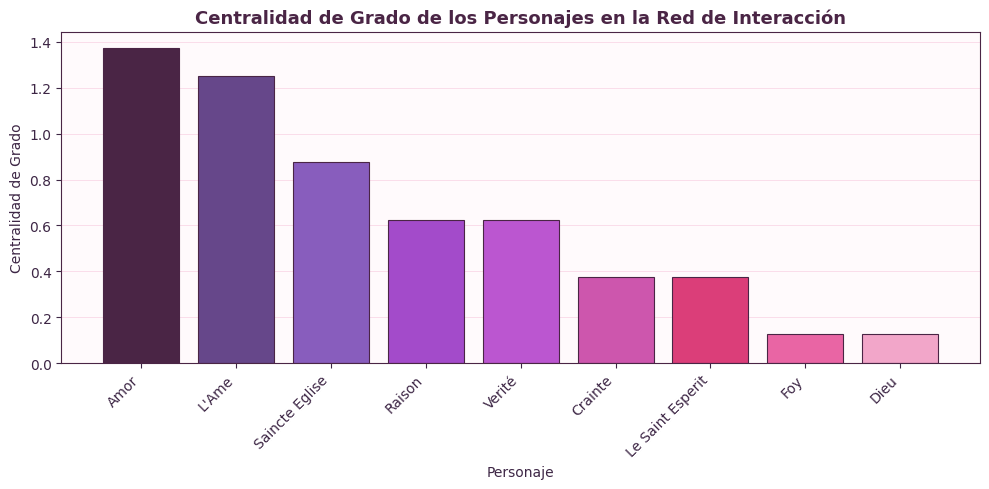

In [22]:
nombres = list(centralidad_ordenada.keys())
valores = list(centralidad_ordenada.values())

plt.figure(figsize=(10, 5))
colores_barras = degradado(len(nombres))
plt.bar(nombres, valores, color=colores_barras, edgecolor=PALETA["violeta_oscuro"], linewidth=0.8)
plt.xticks(rotation=45, ha="right")
plt.title("Centralidad de Grado de los Personajes en la Red de Interacción",
          color=PALETA["violeta_oscuro"], fontsize=13, fontweight="bold")
plt.ylabel("Centralidad de Grado")
plt.xlabel("Personaje")
plt.grid(axis="y", color=PALETA["rosa_palido"], alpha=0.4, linewidth=0.6)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()


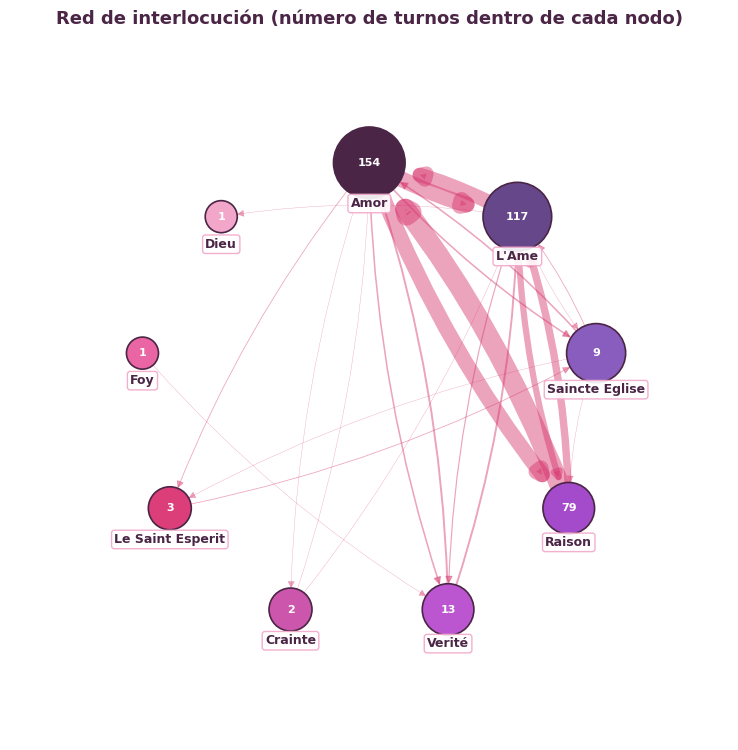

In [23]:
# Red de interlocución. Las etiquetas van DEBAJO de cada nodo, no dentro:
# nombres largos como "Saincte Eglise" o "Le Saint Esperit" no caben en el
# círculo y se desbordaban.
fig, ax = plt.subplots(figsize=(11, 7.6))
# Disposición circular ordenada por centralidad (de mayor a menor, en
# sentido horario desde arriba). Se elige sobre spring_layout porque Amor
# y L'Ame concentran tantas transiciones mutuas que el layout por fuerzas
# las superpone y vuelve ilegibles las etiquetas.
import math
_orden = sorted(G.nodes(), key=lambda n: -centralidad_ordenada.get(n, 0))
pos = {n: (math.sin(2 * math.pi * i / len(_orden)),
           math.cos(2 * math.pi * i / len(_orden)))
       for i, n in enumerate(_orden)}
pesos_aristas = [G[u][v]["weight"] for u, v in G.edges()]
orden_nodos = sorted(G.nodes(), key=lambda n: -centralidad_ordenada.get(n, 0))
colores_nodos = degradado(len(orden_nodos))
mapa_color_nodo = {n: colores_nodos[i] for i, n in enumerate(orden_nodos)}
tamanos = {n: 1700 * centralidad_ordenada.get(n, 0.05) + 320 for n in G.nodes()}

nx.draw_networkx_edges(G, pos, ax=ax, width=[w * 0.28 for w in pesos_aristas],
                       alpha=0.45, edge_color=PALETA["rosa_fuerte"], arrows=True,
                       arrowsize=11, connectionstyle="arc3,rad=0.08",
                       node_size=[tamanos[n] for n in G.nodes()])
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=[tamanos[n] for n in G.nodes()],
                       node_color=[mapa_color_nodo[n] for n in G.nodes()],
                       edgecolors=PALETA["violeta_oscuro"], linewidths=1.2)

# Etiqueta debajo del nodo, a una distancia proporcional a su radio
for n, (x, y) in pos.items():
    radio = (tamanos[n] ** 0.5) / 2 / 72          # radio aproximado, en pulgadas
    desplazamiento = radio / ax.figure.get_size_inches()[1] * 2.2
    ax.text(x, y - desplazamiento - 0.045, n, ha="center", va="top",
            fontsize=9, fontweight="bold", color=PALETA["violeta_oscuro"],
            bbox=dict(boxstyle="round,pad=0.22", facecolor="white",
                      edgecolor=PALETA["rosa_palido"], alpha=0.9))
    ax.text(x, y, str(conteo_agrupado[n]), ha="center", va="center",
            fontsize=8, color="white", fontweight="bold")

ax.set_title("Red de interlocución (número de turnos dentro de cada nodo)",
             color=PALETA["violeta_oscuro"], fontsize=13, fontweight="bold")
ax.set_aspect('equal'); ax.margins(0.22)
ax.axis("off")
plt.tight_layout()
plt.show()


**Nota metodológica**: `nx.degree_centrality()` es la función estándar
de la librería NetworkX — no una métrica inventada para este proyecto. En
un grafo dirigido, mide el número de conexiones distintas (entrantes +
salientes) de cada nodo, normalizado por (n-1). No pesa por la frecuencia
de cada transición: un personaje que interactúa con muchos otros distintos
(aunque poco con cada uno) puede tener más centralidad que otro que habla
mucho pero solo con uno o dos interlocutores fijos. Por eso Saincte Eglise
(6 intervenciones, pero conectada con varios personajes) supera a Raison
(69 intervenciones, pero concentradas mayormente con Amor) en esta métrica
específica — son datos complementarios, no contradictorios, con el conteo
de intervenciones de la sección anterior.

**Para tu tesis**: guardá el ranking de centralidad y la tabla de
transiciones dirigidas — son datos exportables y citables directamente.
Esta es la convención metodológica adoptada: centralidad de grado estándar
de NetworkX, sobre un grafo dirigido de transiciones de turno de diálogo.

## 12. Exportar CSVs

In [24]:
with open("frecuencias_totales.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["palabra", "conteo", "es_stopword"])
    for palabra, conteo in frecuencia_total.most_common():
        w.writerow([palabra, conteo, palabra in STOPWORDS_FR_MEDIO])

campos = ["capitulo", "titulo_capitulo", "total_palabras_capitulo"] + \
         list(VOCABULARIO_CLAVE.keys())
with open("vocabulario_clave_por_capitulo.csv", "w", newline="",
          encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=campos)
    w.writeheader()
    w.writerows(filas_clave)

with open("corpus_completo.txt", "w", encoding="utf-8") as f:
    f.write(corpus_completo)

print("Archivos generados: frecuencias_totales.csv, "
      "vocabulario_clave_por_capitulo.csv, corpus_completo.txt")


Archivos generados: frecuencias_totales.csv, vocabulario_clave_por_capitulo.csv, corpus_completo.txt


## 13. Visualizaciones

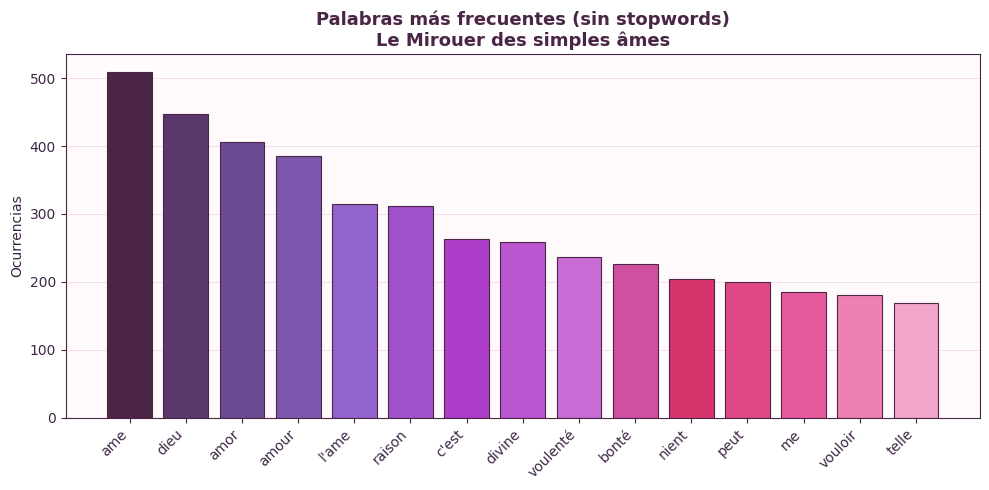

In [25]:
top15 = [(p, c) for p, c in frecuencia_total.most_common()
         if p not in STOPWORDS_FR_MEDIO][:15]
palabras, conteos = zip(*top15)

plt.figure(figsize=(10, 5))
plt.bar(palabras, conteos, color=degradado(len(palabras)),
        edgecolor=PALETA["violeta_oscuro"], linewidth=0.8)
plt.xticks(rotation=45, ha="right")
plt.title("Palabras más frecuentes (sin stopwords)\nLe Mirouer des simples âmes",
          color=PALETA["violeta_oscuro"], fontsize=13, fontweight="bold")
plt.ylabel("Ocurrencias")
plt.grid(axis="y", color=PALETA["rosa_palido"], alpha=0.4, linewidth=0.6)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()


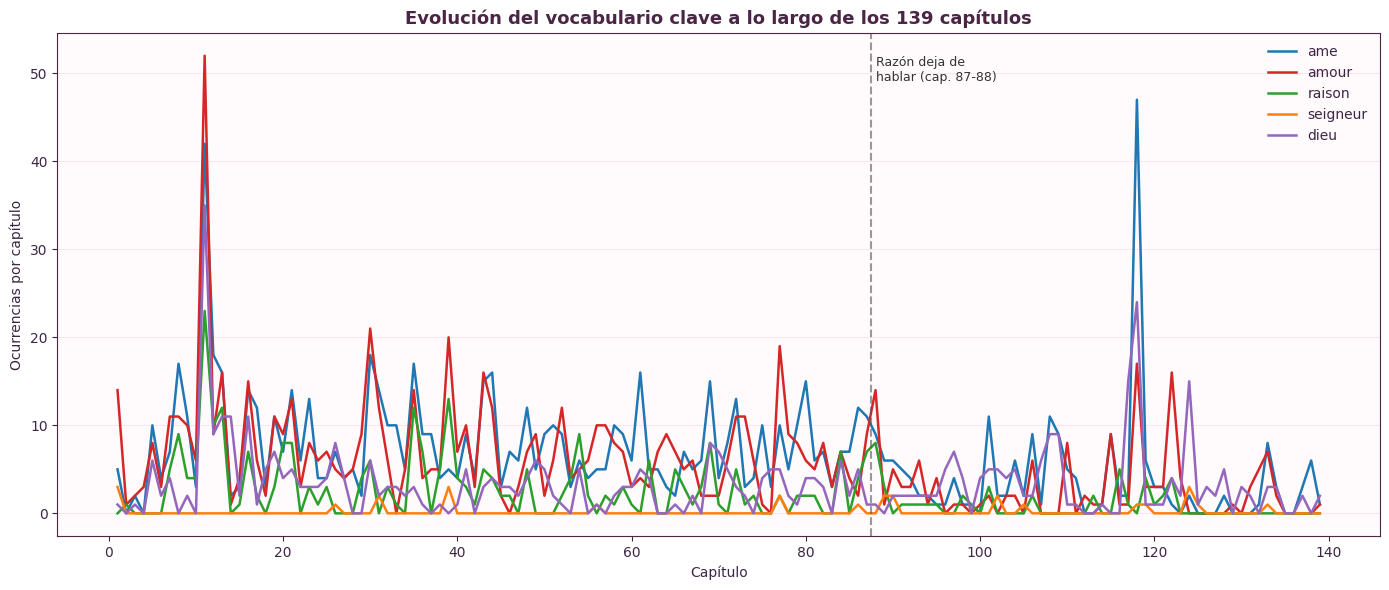

In [26]:
caps_validos = [f for f in filas_clave if f["capitulo"] > 0]
numeros_cap = [f["capitulo"] for f in caps_validos]

# Excepción a la paleta violeta/rosa: este gráfico superpone 5 series y
# necesita colores contrastantes para que las líneas se distingan.
colores_lineas = {
    "ame": "#1f77b4",       # azul
    "amour": "#d62728",     # rojo
    "raison": "#2ca02c",    # verde
    "seigneur": "#ff7f0e",  # naranja
    "dieu": "#9467bd",      # violeta
}

fig, ax = plt.subplots(figsize=(14, 6))
for concepto in ["ame", "amour", "raison", "seigneur", "dieu"]:
    valores = [f[concepto] for f in caps_validos]
    ax.plot(numeros_cap, valores, label=concepto, linewidth=1.8,
            color=colores_lineas[concepto])

ax.axvline(x=87.5, color="#555555", linestyle="--", alpha=0.6)
ax.text(88, ax.get_ylim()[1]*0.9, "Razón deja de\nhablar (cap. 87-88)",
        fontsize=9, color="#333333")

ax.set_xlabel("Capítulo")
ax.set_ylabel("Ocurrencias por capítulo")
ax.set_title("Evolución del vocabulario clave a lo largo de los 139 capítulos",
              color=PALETA["violeta_oscuro"], fontsize=13, fontweight="bold")
ax.legend(frameon=False)
ax.grid(axis="y", color=PALETA["rosa_palido"], alpha=0.3, linewidth=0.6)
plt.tight_layout()
plt.show()


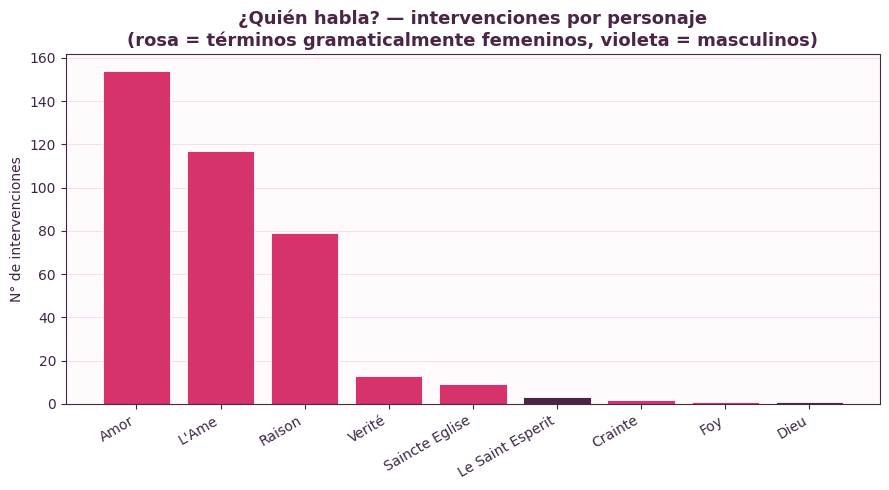

Intervenciones de personajes gramaticalmente FEMENINOS: 375 (98.9%)
Intervenciones de personajes gramaticalmente MASCULINOS: 4 (1.1%)


In [27]:
nombres_hablantes, conteos_hablantes = zip(
    *[(n, c) for n, c in conteo_agrupado.most_common() if c > 0]
)

# Género gramatical de cada personaje (para la comparación visual).
# OJO: "Foy" (la foi) y "Crainte" (la crainte) son FEMENINAS en francés,
# igual que Amor, L'Ame, Raison, Verité y Saincte Eglise. Los únicos dos
# personajes gramaticalmente masculinos de toda la lista son Dieu y
# Le Saint Esperit.
GENERO_PERSONAJES = {
    "Amor": "fem", "L'Ame": "fem", "Raison": "fem", "Verité": "fem",
    "Saincte Eglise": "fem", "Foy": "fem", "Crainte": "fem",
    "Le Saint Esperit": "masc", "Dieu": "masc",
}

plt.figure(figsize=(9, 5))
colores = [PALETA["rosa_fuerte"] if GENERO_PERSONAJES.get(n) == "fem" else PALETA["violeta_oscuro"]
           for n in nombres_hablantes]
plt.bar(nombres_hablantes, conteos_hablantes, color=colores,
        edgecolor="white", linewidth=0.6)
plt.xticks(rotation=30, ha="right")
plt.title("¿Quién habla? — intervenciones por personaje\n"
          "(rosa = términos gramaticalmente femeninos, violeta = masculinos)",
          color=PALETA["violeta_oscuro"], fontsize=13, fontweight="bold")
plt.ylabel("N° de intervenciones")
plt.grid(axis="y", color=PALETA["rosa_palido"], alpha=0.4, linewidth=0.6)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()

fem_total = sum(c for n, c in conteo_agrupado.items()
                if GENERO_PERSONAJES.get(n) == "fem")
masc_total = sum(c for n, c in conteo_agrupado.items()
                  if GENERO_PERSONAJES.get(n) == "masc")
total_clasificado = fem_total + masc_total
print(f"Intervenciones de personajes gramaticalmente FEMENINOS: "
      f"{fem_total} ({fem_total/total_clasificado*100:.1f}%)")
print(f"Intervenciones de personajes gramaticalmente MASCULINOS: "
      f"{masc_total} ({masc_total/total_clasificado*100:.1f}%)")


In [28]:
# Vení a buscar el título de cualquier capítulo por número:
def titulo(n):
    return TITULOS_CAPITULOS[n - 1]

for n in [13, 87, 88, 139]:
    print(f"Cap. {n}: {titulo(n)}")


Cap. 13: Comment raison est contente de la declaration des choses dessusdictes pour les actifs et contemplatifs mais elle demande encore por les communes gens.
Cap. 87: Comment ceste ame est dame des vertuz et fille de la deité.
Cap. 88: Comment amor demande ce que raison demanderoit s'elle estoit en vie, c'est assavoir qui est la mere de raison et des aultres vertuz.
Cap. 139: Comment nature est subtile en plusieurs poins.


## 14. Resultados complementarios

Tres resultados citados en el documento de tesis que no estaban calculados en esta notebook. Se calculan aquí sobre la misma lista de turnos auditada (`turnos_con_capitulo`, 379 turnos), para que todas las cifras provengan de una sola fuente.


### 14.1 Verificación del turno único de Dieu

Separa dos variables: frecuencia léxica de *dieu* (cualquier posición) y turnos con etiqueta de hablante Dieu.


In [29]:
lexica_dieu = len(re.findall(r"\bdieux?\b", corpus_completo, re.IGNORECASE))
etiquetas_con_dieu = re.findall(r"^([^\n.]{0,40}dieu[^\n.]{0,20})\.\s", corpus_completo,
                                re.MULTILINE | re.IGNORECASE)
compuestas = {p: len(re.findall(p, corpus_completo, re.MULTILINE | re.IGNORECASE))
              for p in [r"^Dieu le pere\.", r"^Sire dieu\.", r"^Dieux\."]}

print(f"Frecuencia léxica de dieu/dieux: {lexica_dieu}")
print(f"Turnos de Dieu en la lista auditada: {conteo_agrupado['Dieu']}")
print(f"Etiquetas de inicio de línea que contienen 'dieu': {etiquetas_con_dieu}")
print(f"Variantes compuestas como etiqueta: {compuestas}")
assert conteo_agrupado["Dieu"] == 1


Frecuencia léxica de dieu/dieux: 467
Turnos de Dieu en la lista auditada: 1
Etiquetas de inicio de línea que contienen 'dieu': ['fors dieu', 'Dieu', 'Comment telle ame est de la grace dieu ce qu’elle est', 'Comment pradis n’est aultre chose que dieu veoir', 'L’ame Cy fais dieux']
Variantes compuestas como etiqueta: {'^Dieu le pere\\.': 0, '^Sire dieu\\.': 0, '^Dieux\\.': 0}


### 14.2 Grado de entrada y salida

Descompone la centralidad de grado en sus dos componentes. Explica por qué `nx.degree_centrality()` supera 1 en un grafo dirigido: `G.degree()` suma entrada y salida, y la función divide por n-1.


In [30]:
n = G.number_of_nodes()
print(f"n = {n}, n-1 = {n-1}\n")
print(f"{'Figura':16s} {'entrada':>8s} {'salida':>7s} {'total':>6s} {'total/(n-1)':>12s}")
for fig in centralidad_ordenada:
    e, s = G.in_degree(fig), G.out_degree(fig)
    print(f"{fig:16s} {e:8d} {s:7d} {e+s:6d} {(e+s)/(n-1):12.3f}")
    assert abs((e+s)/(n-1) - centralidad_ordenada[fig]) < 1e-9


n = 9, n-1 = 8

Figura            entrada  salida  total  total/(n-1)
Amor                    5       6     11        1.375
L'Ame                   5       5     10        1.250
Saincte Eglise          3       4      7        0.875
Raison                  3       2      5        0.625
Verité                  3       2      5        0.625
Crainte                 1       2      3        0.375
Le Saint Esperit        2       1      3        0.375
Foy                     0       1      1        0.125
Dieu                    1       0      1        0.125


### 14.3 Función en el turno: preguntas y respuestas

Unidad: cada turno de la lista auditada. **Texto del turno** = desde su etiqueta hasta el primer corte de párrafo o hasta el turno siguiente, lo que ocurra primero. Delimitar hasta el turno siguiente, sin corte de párrafo, arrastra títulos de capítulo y turnos no etiquetados al inicio de línea (ver 14.5): en una prueba previa, el turno único de Dieu absorbía una pregunta de Raison.

- **Pregunta**: el texto del turno termina en `?`.
- **Respuesta**: el turno sigue inmediatamente a una pregunta de otra figura, dentro del mismo capítulo.

Las categorías contradicción, enseñanza y cita de terceros no se calculan: en pruebas previas alcanzaron muestras de 2 a 7 casos.


In [31]:
corte_parrafo = re.compile(r"\r?\n\s*\r?\n")

def texto_de_turno(i):
    pos = turnos_con_capitulo[i][0]
    fin_sig = turnos_con_capitulo[i+1][0] if i+1 < len(turnos_con_capitulo) else len(corpus_completo)
    m = corte_parrafo.search(corpus_completo, pos, fin_sig)
    return corpus_completo[pos:(m.start() if m else fin_sig)].strip()

funcion = defaultdict(Counter)
es_pregunta = []
for i, (pos, fig, cap) in enumerate(turnos_con_capitulo):
    preg = texto_de_turno(i).endswith("?")
    es_pregunta.append(preg)
    funcion[fig]["turnos"] += 1
    if preg:
        funcion[fig]["pregunta"] += 1
    if i > 0:
        _, fig_prev, cap_prev = turnos_con_capitulo[i-1]
        if es_pregunta[i-1] and fig_prev != fig and cap_prev == cap:
            funcion[fig]["respuesta"] += 1

total_preg = sum(f["pregunta"] for f in funcion.values())
total_resp = sum(f["respuesta"] for f in funcion.values())
print(f"{'Figura':16s} {'turnos':>7s} {'preguntas':>10s} {'respuestas':>11s}")
for fig, _ in conteo_agrupado.most_common():
    f = funcion[fig]
    print(f"{fig:16s} {f['turnos']:7d} {f['pregunta']:10d} {f['respuesta']:11d}")
print(f"\nTotal preguntas: {total_preg} | Total respuestas: {total_resp}")

i_dieu = [i for i, t in enumerate(turnos_con_capitulo) if t[1] == "Dieu"][0]
print(f"\nControl — texto del turno de Dieu:\n  {texto_de_turno(i_dieu)[:160]}...")
assert sum(f["turnos"] for f in funcion.values()) == len(turnos_con_capitulo)


Figura            turnos  preguntas  respuestas
Amor                 154          5          29
L'Ame                117          9          13
Raison                79         31           3
Verité                13          2           1
Saincte Eglise         9          1           1
Le Saint Esperit       3          0           0
Crainte                2          2           0
Foy                    1          1           0
Dieu                   1          0           1

Total preguntas: 51 | Total respuestas: 48

Control — texto del turno de Dieu:
  Dieu. Elle ne fera nient dit dieu, mais je feray mon oeuvre en elle sans elle. Car la cognoissance de son nient et la creance de moy l’ont mise si a nient que e...


### 14.4 Tabla consolidada

Una fila por figura, todas las métricas de esta notebook. Es la tabla de referencia para el documento de tesis.


In [32]:
lexica = {"Amor": ["amour","amor","amours"], "L'Ame": ["ame","ames","l'ame"],
          "Raison": ["raison","raisons"], "Verité": ["verité","verite"],
          "Saincte Eglise": ["eglise"], "Le Saint Esperit": ["esperit","esperits","esperiz"],
          "Dieu": ["dieu","dieux"], "Crainte": ["crainte"], "Foy": ["foy"]}

filas = []
for fig, turnos in conteo_agrupado.most_common():
    lex = sum(frecuencia_total.get(v, 0) for v in lexica[fig])
    filas.append([fig, lex, turnos, funcion[fig]["pregunta"], funcion[fig]["respuesta"],
                  G.in_degree(fig), G.out_degree(fig), round(centralidad_ordenada[fig], 3),
                  GENERO_PERSONAJES[fig]])

cab = ["figura","frec_lexica","turnos","preguntas","respuestas",
       "grado_entrada","grado_salida","centralidad","genero_gramatical"]
print(" | ".join(cab))
for f in filas:
    print(" | ".join(str(x) for x in f))

with open("tabla_consolidada.csv", "w", newline="", encoding="utf-8") as fh:
    w = csv.writer(fh); w.writerow(cab); w.writerows(filas)
print(f"\nTotal turnos: {sum(conteo_agrupado.values())} | Total transiciones: {sum(transiciones.values())}")
print("Exportado: tabla_consolidada.csv")


figura | frec_lexica | turnos | preguntas | respuestas | grado_entrada | grado_salida | centralidad | genero_gramatical
Amor | 792 | 154 | 5 | 29 | 5 | 6 | 1.375 | fem
L'Ame | 911 | 117 | 9 | 13 | 5 | 5 | 1.25 | fem
Raison | 312 | 79 | 31 | 3 | 3 | 2 | 0.625 | fem
Verité | 112 | 13 | 2 | 1 | 3 | 2 | 0.625 | fem
Saincte Eglise | 49 | 9 | 1 | 1 | 3 | 4 | 0.875 | fem
Le Saint Esperit | 68 | 3 | 0 | 0 | 2 | 1 | 0.375 | masc
Crainte | 21 | 2 | 2 | 0 | 1 | 2 | 0.375 | fem
Foy | 36 | 1 | 1 | 0 | 0 | 1 | 0.125 | fem
Dieu | 467 | 1 | 0 | 1 | 1 | 0 | 0.125 | masc

Total turnos: 379 | Total transiciones: 243
Exportado: tabla_consolidada.csv


### 14.5 Prueba de sensibilidad: etiquetas en mitad de línea

El extractor solo reconoce etiquetas al inicio de línea. Se buscan etiquetas de hablante que aparecen en mitad de línea, tras un fin de oración y seguidas de mayúscula. No se incorporan a la base oficial de 379 turnos; se recalcula con ellas para comprobar si alteran algún resultado.


In [33]:
pat_linea = re.compile(r"(?<=[.?!:] )(" + "|".join(re.escape(v) for v in _variantes_ordenadas) + r")\. (?=[A-ZÀ-Ý])")
en_linea = [(m.start(1), INVERSO_WHITELIST[m.group(1)]) for m in pat_linea.finditer(corpus_completo)]
print(f"Etiquetas en mitad de línea: {len(en_linea)}")
for pos, fig in en_linea:
    print(f"  cap. {capitulo_de(pos):3d}  {fig:8s}  {corpus_completo[pos:pos+70]!r}")

turnos_ext = sorted(set([(p, g) for p, g, _ in turnos_con_capitulo] + en_linea))
turnos_ext = [(p, g, capitulo_de(p)) for p, g in turnos_ext]
conteo_ext = Counter(g for _, g, _ in turnos_ext)
trans_ext = Counter()
for i in range(1, len(turnos_ext)):
    a, b = turnos_ext[i-1], turnos_ext[i]
    if a[2] == b[2] and a[1] != b[1]:
        trans_ext[(a[1], b[1])] += 1
G_ext = nx.DiGraph()
G_ext.add_nodes_from(GRUPOS)
for (o, d), w in trans_ext.items():
    G_ext.add_edge(o, d, weight=w)
cent_ext = nx.degree_centrality(G_ext)

fem_ext = sum(c for g, c in conteo_ext.items() if GENERO_PERSONAJES[g] == "fem")
print(f"\nTurnos: {len(turnos_con_capitulo)} -> {len(turnos_ext)} | "
      f"transiciones: {sum(transiciones.values())} -> {sum(trans_ext.values())}")
print(f"Femeninos: {fem_ext}/{len(turnos_ext)} = {fem_ext/len(turnos_ext)*100:.1f}%")
print(f"\n{'Figura':16s} {'turnos':>13s} {'centralidad':>15s}")
for g in centralidad_ordenada:
    print(f"{g:16s} {conteo_agrupado[g]:5d} -> {conteo_ext[g]:4d} {centralidad_ordenada[g]:6.3f} -> {cent_ext[g]:.3f}")

orden_base = sorted(GRUPOS, key=lambda g: -centralidad_ordenada[g])
orden_ext = sorted(GRUPOS, key=lambda g: -cent_ext[g])
print(f"\nRanking de centralidad sin cambios: {orden_base == orden_ext}")
print(f"Turnos de Dieu y Le Saint Esperit sin cambios: "
      f"{conteo_ext['Dieu'] == conteo_agrupado['Dieu'] and conteo_ext['Le Saint Esperit'] == conteo_agrupado['Le Saint Esperit']}")


Etiquetas en mitad de línea: 4
  cap.  22  L'Ame     'L’ame. Adonc dit ceste ame a la maleureuse nature qui par maintez jour'
  cap.  36  Amor      'Amour. C’est verité tres doulce ame dit amour je le vous octroie et co'
  cap.  46  Raison    'Raison. Hee dea dit raison, ose l’en bien appeler nient chose qui est '
  cap.  87  L'Ame     'L’ame. Voire dit ceste ame, mais ce semble a raison merveilleux langag'

Turnos: 379 -> 383 | transiciones: 243 -> 247
Femeninos: 379/383 = 99.0%

Figura                  turnos     centralidad
Amor               154 ->  155  1.375 -> 1.375
L'Ame              117 ->  119  1.250 -> 1.250
Saincte Eglise       9 ->    9  0.875 -> 0.875
Raison              79 ->   80  0.625 -> 0.625
Verité              13 ->   13  0.625 -> 0.625
Crainte              2 ->    2  0.375 -> 0.375
Le Saint Esperit     3 ->    3  0.375 -> 0.375
Foy                  1 ->    1  0.125 -> 0.125
Dieu                 1 ->    1  0.125 -> 0.125

Ranking de centralidad sin cambios: True
Tu

## 15. Concordancias metalingüísticas (capítulo 8 de la tesis)

Pregunta: ¿el texto comenta alguna vez el género de las figuras que lo enuncian? Se compara con los términos que funcionan como comentario sobre otras convenciones textuales.

**Reglas de conteo:**
- Singular y plural se cuentan por separado (`\bpersonne\b` no incluye *personnes*). El total de una familia es la suma, sin solapamiento.
- Las fórmulas incluidas en otra (*de ce livre* dentro de *ce livre*; *de mon entendement* dentro de *mon entendement*) se informan como subconjunto, nunca se suman.
- Se incluyen las abreviaturas del manuscrito (*prsonne*, *psonne*).
- La clasificación de cada ocurrencia (trinitaria, ordinaria, metalingüística) es manual: esta sección imprime los contextos con su capítulo para esa lectura y exporta `clasificacion_completa.txt`.


In [34]:
def contar(patron):
    return len(re.findall(patron, corpus_completo, re.IGNORECASE))

def contextos(patron, ventana=110):
    return [(capitulo_de(m.start()),
             corpus_completo[max(0, m.start()-ventana):m.end()+ventana].replace("\r", "").replace("\n", " ").strip())
            for m in re.finditer(patron, corpus_completo, re.IGNORECASE)]

B = r"\b"
terminos = {
    "personne": B+"personne"+B, "personnes": B+"personnes"+B,
    "prsonne/psonne (abrev.)": r"\bp(?:r)?sonnes?\b",
    "semblance": B+"semblance"+B, "semblances": B+"semblances"+B,
    "figure": B+"figure"+B, "figures": B+"figures"+B,
    "livre": B+"livre"+B, "livres": B+"livres"+B,
    "entendement": B+"entendement"+B, "entendemens": B+"entendemens"+B,
    "exemple": B+"exemple"+B, "exemples": B+"exemples"+B,
    "clerc": B+"clerc"+B, "clers": B+"clers"+B, "clergie": B+"clergie"+B,
    "senefiance": B+"senefiance"+B, "allegorie": B+"allegorie"+B,
    "latin": B+"latin"+B, "romanz": B+"romanz"+B, "françois": B+"françois"+B,
}
conteos_meta = {t: contar(p) for t, p in terminos.items()}
for t, n in conteos_meta.items():
    print(f"  {t:26s} {n:4d}")


  personne                     20
  personnes                     6
  prsonne/psonne (abrev.)      13
  semblance                     7
  semblances                    0
  figure                        2
  figures                       0
  livre                        68
  livres                        0
  entendement                  62
  entendemens                   3
  exemple                      19
  exemples                      2
  clerc                         1
  clers                         4
  clergie                       0
  senefiance                    0
  allegorie                     0
  latin                         0
  romanz                        0
  françois                      0


### 15.1 Familia *personne*: contextos para clasificación manual


In [35]:
for etiqueta, patron in [("personne", terminos["personne"]), ("personnes", terminos["personnes"]),
                         ("prsonne/psonne", terminos["prsonne/psonne (abrev.)"])]:
    ctx = contextos(patron)
    print(f"\n=== {etiqueta.upper()} — {len(ctx)} ===")
    for i, (c, t) in enumerate(ctx, 1):
        print(f"[{i}] cap. {c}: …{t}…")

total_familia = conteos_meta["personne"] + conteos_meta["personnes"] + conteos_meta["prsonne/psonne (abrev.)"]
print(f"\nTotal familia personne: {total_familia}")



=== PERSONNE — 20 ===


[1] cap. 14: …’incarnacion, et le filz aussi, et le saint esperit aussi ainsi que dieu le pere a joinct nature humaine a la personne de dieu le filz, et la personne de dieu le filz l’a joincte à la personne de luy mesmes, et dieu le saint esp…
[2] cap. 14: …et le saint esperit aussi ainsi que dieu le pere a joinct nature humaine a la personne de dieu le filz, et la personne de dieu le filz l’a joincte à la personne de luy mesmes, et dieu le saint esperit l’a joincte à la personne d…
[3] cap. 14: …e pere a joinct nature humaine a la personne de dieu le filz, et la personne de dieu le filz l’a joincte à la personne de luy mesmes, et dieu le saint esperit l’a joincte à la personne de dieu le filz. Si que le pere a en luy un…
[4] cap. 14: …a personne de dieu le filz l’a joincte à la personne de luy mesmes, et dieu le saint esperit l’a joincte à la personne de dieu le filz. Si que le pere a en luy une seule nature, c’est assavoir nature divine, et la personne du fi…
[5] cap. 14: …à la pers

### 15.2 Fórmulas metalingüísticas sobre otras convenciones


In [36]:
formulas = {
    "ce livre": contar(r"\bce livre\b"),
    "  de ellas, en ce livre": contar(r"\ben ce livre\b"),
    "  de ellas, de ce livre": contar(r"\bde ce livre\b"),
    "mon entendement": contar(r"\bmon entendement\b"),
    "  de ellas, de mon entendement": contar(r"\bde mon entendement\b"),
}
for f, n in formulas.items():
    print(f"  {f:32s} {n:4d}")

tabla_meta = {
    "Sobre el género de las figuras": 0,
    "Sobre el propio libro (ce livre)": formulas["ce livre"],
    "Sobre el propio entendimiento (mon entendement)": formulas["mon entendement"],
    "Sobre la forma ejemplar (exemple, exemples)": conteos_meta["exemple"] + conteos_meta["exemples"],
    "Sobre los clérigos (clerc, clers)": conteos_meta["clerc"] + conteos_meta["clers"],
}
print()
for k, v in tabla_meta.items():
    print(f"  {k:50s} {v:4d}")
total_otras = sum(v for k, v in tabla_meta.items() if k != "Sobre el género de las figuras")
print(f"  {'Total sobre otras convenciones':50s} {total_otras:4d}")

assert formulas["  de ellas, en ce livre"] <= formulas["ce livre"]
assert formulas["  de ellas, de mon entendement"] <= formulas["mon entendement"]


  ce livre                           63
    de ellas, en ce livre             4
    de ellas, de ce livre            14
  mon entendement                     6
    de ellas, de mon entendement      4

  Sobre el género de las figuras                        0
  Sobre el propio libro (ce livre)                     63
  Sobre el propio entendimiento (mon entendement)       6
  Sobre la forma ejemplar (exemple, exemples)          21
  Sobre los clérigos (clerc, clers)                     5
  Total sobre otras convenciones                       95


### 15.3 Pasajes citados en la tesis: capítulo de origen


In [37]:
pasajes = {
    "semblance n'est mie verité": r"semblance n.est mie verit",
    "ceste ame qui escripsit ce livre ... socte": r"escripsit ce livre",
    "la personne de raison": r"personne de raison",
}
for nombre, patron in pasajes.items():
    caps = sorted({capitulo_de(m.start()) for m in re.finditer(patron, corpus_completo, re.IGNORECASE)})
    print(f"  {nombre:45s} cap. {caps}")


  semblance n'est mie verité                    cap. [97]


  ceste ame qui escripsit ce livre ... socte    cap. [97]
  la personne de raison                         cap. [88]


In [38]:
with open("clasificacion_completa.txt", "w", encoding="utf-8") as fh:
    for t, p in terminos.items():
        ctx = contextos(p, ventana=120)
        fh.write(f"\n{'='*80}\n{t.upper()} — total: {len(ctx)}\n{'='*80}\n")
        for i, (c, texto) in enumerate(ctx, 1):
            fh.write(f"\n[{i}] cap. {c}: {texto}\n")
print("Exportado: clasificacion_completa.txt")


Exportado: clasificacion_completa.txt


## Apéndice A — Auditoría de puntuación de hablante

**Problema.** La extracción original de etiquetas de hablante usaba un
patrón genérico (`[Mayúscula][texto]{2,40}\.`) que depende de que el
manuscrito tenga el punto esperado tras el nombre del personaje. Esto
no siempre ocurre: el texto usa a veces `:` en vez de `.`, a veces no
usa ningún signo, y a veces el título de un capítulo queda pegado al
primer turno de diálogo sin la línea de número de capítulo que
normalmente los separa.

**Método.** Se migró a un regex de lista cerrada (solo las variantes
ya catalogadas en `GRUPOS`), y se buscó cada aparición de cada nombre
de personaje NO seguida de punto inmediato. Se revisaron a mano los 62
candidatos resultantes (13 Amor, 13 Raison, 30 L'Ame, 4 Saincte Eglise,
2 Verité; cero en Le Saint Esperit, Dieu, Crainte, Foy), clasificando
cada uno en seis categorías:

| Categoría | Significado |
|---|---|
| Genuino | Turno real de diálogo → se agrega al conteo |
| Ya contado | La variante ya tiene su propio punto más adelante en la frase (ej. "L'ame franche.") → no se duplica |
| Fusión título+turno | Título de capítulo pegado al primer turno sin separador → se separa manualmente |
| Turno de otro hablante | La fusión esconde un turno de un personaje distinto al que aparece primero en el texto |
| No es turno | Verso del poema inicial o de la canción del cap. 122 → no es diálogo |
| Voz poética | El personaje es sujeto gramatical de un verbo dentro de un verso cantado, sin abrir turno de diálogo — categoría intermedia entre mención léxica e interlocución (ver caso Verité, cap. 122) |

**Resultado.** 45 turnos genuinos adicionales confirmados. Un hallazgo
adicional durante la revisión: tres casos de Raison inicialmente
marcados como ambiguos ("Raison dit amor...") se resolvieron al
notar que "amor"/"amour" aparecía en **minúscula** — es decir, el
sustantivo común "el amor" (tema del que habla Raison), no el nombre
del personaje Amor (que en todo el corpus aparece siempre en
mayúscula cuando es hablante). Raison es la única hablante en los
tres casos.

Un solo caso quedó sin resolver como turno de diálogo — no por
ambigüedad, sino porque se determinó que pertenece a la canción del
capítulo 122 (voz poética de Verité, no interlocución).

**Efecto sobre los resultados.** El total de intervenciones
clasificables sube de 331 a **379** (+14.5%). El **ranking de
personajes por centralidad de grado no cambia en ningún puesto** —
Amor se mantiene en 1.375 exacto, Dios y Foy en 0.125 exacto. El
hallazgo central (concentración extrema de la voz discursiva en
entidades gramaticalmente femeninas) se sostiene con los números
corregidos y se refuerza levemente: pasa de 98.8% a 98.9%, porque los
45 casos recuperados son todos de personajes femeninos.

| Personaje | Antes | Corregido | Diferencia |
|---|---|---|---|
| Amor | 145 | 154 | +9 |
| L'Ame | 92 | 117 | +25 |
| Raison | 69 | 79 | +10 |
| Saincte Eglise | 6 | 9 | +3 |
| Verité | 12 | 13 | +1 |
| Le Saint Esperit | 3 | 3 | 0 |
| Dieu | 1 | 1 | 0 |
| Crainte | 2 | 2 | 0 |
| Foy | 1 | 1 | 0 |
| **Total** | **331** | **379** | **+48*** |

*El total de casos confirmados (45) más los 3 casos de Raison resueltos
por mayúscula en una segunda pasada.

**Casos sin resolver (documentados, no forzados):** ninguno queda
pendiente al cierre de esta auditoría — el único caso ambiguo
remanente (Verité, cap. 122) se resolvió como voz poética, no como
turno de diálogo.


## Próximos pasos posibles

- **Concordancias**: buscar todas las oraciones donde aparece "loingpres",
  "néant" o "deité" con su contexto inmediato.
- **N-gramas**: bigramas/trigramas más frecuentes para detectar fórmulas
  fijas del estilo de Porete (ej. "dit amor", "ceste ame").
- **Comparación con la traducción inglesa de Babinsky** o la francesa
  moderna de Huot de Longchamp, si conseguís los textos.
- **Red de personajes**: quién le "habla" a quién (Amor, Razón, el Alma,
  las Virtudes, Verdad) capítulo a capítulo — el libro es casi un diálogo
  teatral.
